# 그래프는 왜 극좌표 CNN보다 약한가 — 개입 실험

## 출발점

```
GIN[base]   0.8418 ± 0.0159
PolarCNN    0.9060 ± 0.0052      +0.064, 개선 5/5 fold
파라미터    176,979  vs  191,216      (용량은 거의 같다)
```

3-hop 커버율과 CNN 대비 열세의 상관이 **r = −0.714** 였다.

**그런데 이건 상관이지 인과가 아니다.** 커버율이 낮은 클래스(Random 12.9%, Near-full 8.5%)는
결함 수가 많은 클래스이기도 하다. 교란 변수다. 심사에서 "결함 수 때문 아니냐"고
물으면 답이 없다.

## 그래서 개입한다

| 가설 | 개입 | 예측 |
|---|---|---|
| **H1 수용 영역** | 가상 노드로 그래프에 전역 시야 부여 | **정방향** 좋아져야 함 |
| | CNN 풀링을 빼 시야만 축소 | **역방향** 나빠져야 함 |
| | 층 3 → 5 → 7 | **용량반응** 단조 개선 |
| **H2 정보 비대칭** | CNN 마스크 채널 제거 | 나빠져야 함 |
| **H3 극좌표 표현** | 직교좌표 CNN | 극좌표가 나아야 함 |
| **H4 용량** | GIN·CNN 파라미터 스케일링 | 용량으로 설명되면 안 됨 |

**세 방향이 같은 결론을 가리켜야 인과가 성립한다.** 하나만으로는 다른 설명이
가능하지만, 정방향·역방향·용량반응이 일치하면 대안 설명이 거의 남지 않는다.

## 설계에서 지킨 것

**가상 노드는 파라미터를 +1.3%만 늘린다.**
```
GIN 기준     176,979
+ 가상 노드  179,291   +1.3%    ← 시야만 바뀜
층 5         243,541  +37.6%    ← 용량도 함께 늘어남
층 7         310,103  +75.2%
```
층·k 를 늘리면 "용량이 늘어서 좋아진 것"이라는 반박이 가능하지만, 가상 노드는
그 반박이 봉쇄된다. **H1 을 가르는 가장 깨끗한 개입이다.**

**CNN 풀링 축소는 파라미터가 전혀 안 바뀐다.** conv 4개는 그대로 두고 MaxPool 만
뺀다. 풀링 하나당 최종 화소의 시야가 절반이 된다.

**직교좌표 CNN 은 아키텍처·파라미터가 극좌표와 완전히 동일하다.** 입력 이미지와
순환 패딩 해제만 다르다.

## ⚠️ 이 실험이 없으면 논문이 성립하지 않는 것 둘

1. **직교좌표 CNN** — 지금까지 잰 것은 "이미지 vs 그래프"이지 "**극좌표** vs 그래프"가
   아니다. 직교좌표도 같은 성능이면 제목에서 "극좌표"를 빼야 한다.
2. **마스크 채널 제거** — CNN 은 웨이퍼 형상을 전 영역 받고, 그래프는 결함 주변
   반경 4다이(`local_ratio`)만 받는다. **"표현의 차이인가 정보량의 차이인가"** 에
   답해야 한다. 로트 지문 우려도 함께 해소된다.

## 이번 판에서 달라진 것

1. **가상 노드 집계를 합에서 평균으로 고쳤다** (부록 A.3). 첫 구현은 노드 240~5,494개를
   그냥 더해 모든 노드에 뿌렸다. 노드 수가 20배 차이 나므로 큰 웨이퍼에서는 노드
   특징이 가상 노드에 덮이고 작은 웨이퍼에서는 아무 일도 안 일어난다. 그래서 나온
   0.7976 은 **시야의 효과가 아니라 정규화 결함의 효과**다. H1 정방향은 이 수치로
   판정할 수 없다. 파라미터 수는 두 방식이 완전히 같다(179,291).
2. **1 fold 스크리닝 단계를 없앴다.** 어떤 개입이 의미 있는지 이미 알고 있으므로
   전 설정(9종)을 처음부터 5 fold 로 돌린다(§11). 옛 스크리닝 셀은 기록 가치가 있어
   부록 A 에 남겼고, 실행하지 않는다.
3. **조기 종료를 고쳤다.** `patience` 10 → 20, `min_epochs` 30 을 새로 뒀다.
   관측된 최대 갱신 간격이 6~7 epoch 이라 10 은 여유가 3~4 뿐이었고, `CartesianCNN`
   fold 0 은 epoch 14 에서 최고를 찍고 24 에 종료돼 상승 곡선 중간에 잘린 것으로
   보인다(다른 fold 는 0.902~0.905).
4. **캐시 키에 학습 조건을 넣었다.** `_p20_e100` 접미사가 붙어 옛 결과와 파일이
   갈린다. 옛 캐시는 지우지 않는다 — 공존한다.

## EPOCHS = 100

이전 실행에서 `PolarCNN` 은 최고 epoch 38 / 종료 48 로 **상한 50에 걸려 있었다**
(GIN 은 21~31 로 여유). 공정성 방어를 위해 양쪽 모두 100으로 올리고 기준선을
다시 잰다.

## 반드시 GPU 런타임으로


# 1. 환경 준비


In [2]:
!pip install -q torch_geometric

import os, sys, time, math, json, random, hashlib, warnings, collections
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("[경고] GPU 런타임이 아니다.")

from google.colab import drive
drive.mount('/content/drive')

DRIVE      = '/content/drive/MyDrive/ACK2026_Wafer'
RAW_PKL    = f'{DRIVE}/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl'
SPEC_DIR   = f'{DRIVE}/Train_Model/spec_v1'
SPLIT_PATH = f'{SPEC_DIR}/split_sealed_grouped_seed42.npz'
ABL_CACHE  = f'{SPEC_DIR}/ablation_results'
ABL_CKPT   = f'{SPEC_DIR}/ablation_checkpoints'

POLAR_NPZ  = '/content/wafer_spec_polar.npz'
CART_NPZ   = '/content/wafer_spec_cart.npz'
DRIVE_POLAR= f'{DRIVE}/Train_Model/Training_Data/wafer_spec_polar.npz'
DRIVE_CART = f'{DRIVE}/Train_Model/Training_Data/wafer_spec_cart.npz'

for p in (ABL_CACHE, ABL_CKPT, os.path.dirname(DRIVE_POLAR)):
    os.makedirs(p, exist_ok=True)

assert os.path.exists(SPLIT_PATH), (
    f"분할 파일이 없다: {SPLIT_PATH}\n"
    "먼저 ACK2026_Wafer_Spec_Colab.ipynb 로 분할을 만들어야 한다.")
print("분할 파일 확인:", SPLIT_PATH)


torch 2.11.0+cu128 | CUDA: True
Mounted at /content/drive
분할 파일 확인: /content/drive/MyDrive/ACK2026_Wafer/Train_Model/spec_v1/split_sealed_grouped_seed42.npz


# 2. 전처리 함수


In [3]:
"""WM-811K 웨이퍼 맵 전처리 v2.

v1(`Data_Preprocessing/Wafer Data Preprocessing6.ipynb`) 대비 변경점

1. 노이즈 필터를 '다이 피치' 단위로 재정의하고, 삭제 대신 플래그로 보존
   - v1: eps=0.10 (정규화 좌표) -> 웨이퍼 크기에 따라 실제 반경이 1.3~8.6 다이로 요동.
     Center 60%, Scratch 59%, Loc 51% 의 결함 다이가 삭제되고 있었음.
   - v2: DBSCAN 을 다이(die) 단위 좌표에서 수행하여 eps 가 항상 동일한 물리적 거리.
     노이즈로 판정된 점도 지우지 않고 `is_noise` 특징/채널로 남김.

2. 유효 다이(waferMap > 0) 기준 반경 정규화
   - v1: rmax = max(w, h) / 2 로 x, y 를 동시에 나눔 -> 종횡비가 다른 웨이퍼(전체의 66%)
     에서 원이 타원으로 왜곡. 최외곽 반경이 웨이퍼마다 0.955~1.037 로 흔들림.
   - v2: 중심 = 유효 다이 무게중심, R = 유효 다이의 최대 반경.
     정의상 모든 결함 다이가 r <= 1 이 되어 클리핑 손실이 0.

3. 극좌표 이미지를 3채널 밀도 맵으로 교체
   - ch0 결함 밀도 = (빈 내 결함 다이 수) / (빈 내 유효 다이 수)
   - ch1 유효 다이 마스크 = 그 위치에 웨이퍼가 존재하는가
   - ch2 노이즈 판정 결함 밀도
   - v1 은 1채널 이진 대입(`= 1.0`)이라 Edge-Ring 결함의 19% 가 같은 픽셀에 겹쳐 소실됐고,
     "결함 없음"과 "다이 없음"을 구분할 수 없었음.

5. GCN 입력 강화
   - 반경 기반 그래프 대신 k-NN 그래프(k 고정) -> 평균 차수가 0.38~73.8 로 벌어지던 문제 해소.
   - 노드 특징을 (x, y) 2차원에서 11차원으로 확장.

주의: 전처리는 라벨(failureType)을 일절 사용하지 않는다. 패턴별로 파라미터를 다르게 주면
추론 시점에 재현할 수 없는 라벨 누수가 된다.
"""


import numpy as np
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

# 8대 불량 패턴 라벨 인코딩. 전처리·데이터셋·학습이 공유하므로 여기 한 곳에만 둔다.
LABEL_MAP = {
    "Center": 0, "Donut": 1, "Edge-Loc": 2, "Edge-Ring": 3,
    "Loc": 4, "Random": 5, "Scratch": 6, "Near-full": 7,
}
REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

# 노드 특징 벡터의 열 인덱스. 증강(회전/반전)이 이 순서에 의존하므로 변경 시 주의.
FEAT_X, FEAT_Y = 0, 1          # 회전/반전 대상
FEAT_R = 2
FEAT_COS, FEAT_SIN = 3, 4      # 회전/반전 대상
FEAT_DENS2 = 5
FEAT_DENS4 = 6
FEAT_KNN_DIST = 7
FEAT_LOCAL_RATIO = 8
FEAT_IS_NOISE = 9
FEAT_LOG_N = 10
NUM_NODE_FEATURES = 11

# 그래프 수준 스칼라 (분류기에 직접 주입)
NUM_GRAPH_SCALARS = 4

POLAR_CHANNELS = 3


class WaferPreprocessorV2:
    """웨이퍼 맵 한 장을 (그래프, 극좌표 이미지, 스칼라) 3종 표현으로 변환한다.

    Parameters
    ----------
    r_bins, theta_bins : 극좌표 이미지 해상도.
    knn_k : 각 결함 노드가 연결할 최근접 이웃 수. 방향성 엣지로 저장하고 학습 시 대칭화한다.
    noise_eps_dies : DBSCAN 반경. **다이 개수 단위**라 웨이퍼 크기와 무관하게 일정하다.
    noise_min_samples : DBSCAN 최소 샘플 수.
    drop_noise : True 면 노이즈 판정 결함을 실제로 삭제한다. 기본 False(플래그만 부여).
        Random 패턴은 산발 노이즈 자체가 클래스 정의이고 Scratch 는 폭 1~2 다이의 선이라
        삭제하면 신호가 사라진다. 삭제 대신 모델이 판단하도록 정보만 넘긴다.
    density_radii : 국소 밀도 특징을 계산할 반경(다이 단위).
    """

    def __init__(
        self,
        r_bins: int = 64,
        theta_bins: int = 64,
        knn_k: int = 8,
        noise_eps_dies: float = 2.0,
        noise_min_samples: int = 3,
        drop_noise: bool = False,
        density_radii: tuple[float, float] = (2.0, 4.0),
        include_polar: bool = True,
        include_cartesian: bool = False,
    ):
        self.r_bins = r_bins
        self.theta_bins = theta_bins
        self.knn_k = knn_k
        self.noise_eps_dies = noise_eps_dies
        self.noise_min_samples = noise_min_samples
        self.drop_noise = drop_noise
        self.density_radii = density_radii
        # 순수 graph 모델(GCN/GraphSAGE/GAT ...)만 비교할 때는 극좌표 이미지가 필요 없다.
        # 끄면 저장 용량과 RAM 이 크게 줄고 전처리도 빨라진다.
        # theta_bins 는 이미지가 없어도 증강 회전 단위로 계속 쓰이므로 그대로 둔다.
        self.include_polar = include_polar
        self.include_cartesian = include_cartesian

    # ------------------------------------------------------------------
    # [개선 2] 웨이퍼 기하 구조 추정
    # ------------------------------------------------------------------
    @staticmethod
    def wafer_geometry(wafer_map: np.ndarray):
        """유효 다이만으로 웨이퍼 원의 중심과 반경을 추정한다.

        배열 중심 `(w/2, h/2)` 과 `max(w, h)/2` 를 쓰던 v1 과 달리 종횡비, 여백,
        다이 크기에 영향받지 않는다. 반환하는 R 은 유효 다이의 최대 반경이므로
        모든 유효 다이(=결함 다이 포함)가 r <= 1 을 만족한다.
        """
        vy, vx = np.nonzero(wafer_map > 0)
        if len(vx) == 0:
            return None
        cx, cy = vx.mean(), vy.mean()
        dv = np.hypot(vx - cx, vy - cy)
        radius = float(dv.max())
        if radius <= 0:
            return None
        return vx, vy, cx, cy, radius

    # ------------------------------------------------------------------
    def process_wafer(self, wafer_map: np.ndarray) -> dict | None:
        wafer_map = np.asarray(wafer_map)
        geom = self.wafer_geometry(wafer_map)
        if geom is None:
            return None
        vx, vy, cx, cy, radius = geom

        by, bx = np.nonzero(wafer_map == 2)
        if len(bx) == 0:
            return None

        # 다이 단위 좌표(1 = 다이 1개 간격). 거리 기반 파라미터는 전부 이 좌표계에서 정의한다.
        defect_px = np.column_stack((bx - cx, cy - by)).astype(np.float64)
        die_px = np.column_stack((vx - cx, cy - vy)).astype(np.float64)

        # [개선 1] 다이 단위 DBSCAN -> 웨이퍼 크기와 무관하게 동일한 물리적 필터
        if len(defect_px) >= self.noise_min_samples:
            labels = DBSCAN(
                eps=self.noise_eps_dies, min_samples=self.noise_min_samples
            ).fit(defect_px).labels_
            is_noise = (labels == -1)
        else:
            is_noise = np.ones(len(defect_px), dtype=bool)

        if self.drop_noise and (~is_noise).sum() >= 3:
            defect_px = defect_px[~is_noise]
            is_noise = is_noise[~is_noise]

        node_feat = self._node_features(defect_px, die_px, radius, is_noise)
        edge_index = self._knn_edges(defect_px)
        scalars = np.array(
            [
                np.log1p(len(defect_px)) / 10.0,
                len(defect_px) / len(die_px),
                np.log1p(len(die_px)) / 10.0,
                radius / 100.0,
            ],
            dtype=np.float32,
        )

        result = {
            "node_feat": node_feat.astype(np.float16),
            "edge_index": edge_index.astype(np.int16),  # 노드 수 < 32767 보장
            "scalars": scalars,
            "n_defect": int(len(defect_px)),
            "n_die": int(len(die_px)),
            "radius": float(radius),
            "noise_ratio": float(is_noise.mean()),
        }
        if self.include_polar:
            result["polar"] = self._polar_density(
                defect_px, die_px, radius, is_noise).astype(np.float16)
        if self.include_cartesian:
            result["cart"] = self._cartesian_density(
                defect_px, die_px, radius, is_noise).astype(np.float16)
        return result

    # ------------------------------------------------------------------
    # [개선 5] 노드 특징 11차원
    # ------------------------------------------------------------------
    def _node_features(self, defect_px, die_px, radius, is_noise) -> np.ndarray:
        n = len(defect_px)
        x = defect_px[:, 0] / radius
        y = defect_px[:, 1] / radius
        r = np.hypot(x, y)
        theta = np.arctan2(y, x)

        defect_tree = cKDTree(defect_px)
        die_tree = cKDTree(die_px)

        r_small, r_large = self.density_radii
        # 자기 자신이 항상 포함되므로 -1
        dens_small = np.array(defect_tree.query_ball_point(defect_px, r_small, return_length=True)) - 1.0
        dens_large = np.array(defect_tree.query_ball_point(defect_px, r_large, return_length=True)) - 1.0
        die_large = np.array(die_tree.query_ball_point(defect_px, r_large, return_length=True))

        # k-NN 평균 거리(다이 단위). 노드가 k+1개 미만이면 있는 만큼만 사용한다.
        k = min(self.knn_k + 1, n)
        if k >= 2:
            dists, _ = defect_tree.query(defect_px, k=k)
            knn_mean = dists[:, 1:].mean(axis=1)
        else:
            knn_mean = np.full(n, 10.0)

        feat = np.zeros((n, NUM_NODE_FEATURES), dtype=np.float32)
        feat[:, FEAT_X] = x
        feat[:, FEAT_Y] = y
        feat[:, FEAT_R] = r
        feat[:, FEAT_COS] = np.cos(theta)
        feat[:, FEAT_SIN] = np.sin(theta)
        feat[:, FEAT_DENS2] = np.log1p(np.clip(dens_small, 0, None))
        feat[:, FEAT_DENS4] = np.log1p(np.clip(dens_large, 0, None))
        feat[:, FEAT_KNN_DIST] = np.clip(knn_mean, 0, 20.0) / 20.0
        feat[:, FEAT_LOCAL_RATIO] = np.clip(dens_large, 0, None) / np.maximum(die_large, 1.0)
        feat[:, FEAT_IS_NOISE] = is_noise.astype(np.float32)
        feat[:, FEAT_LOG_N] = np.log1p(n) / 10.0
        return feat

    # ------------------------------------------------------------------
    # [개선 5] 고정 반경 대신 k-NN 그래프
    # ------------------------------------------------------------------
    def _knn_edges(self, defect_px) -> np.ndarray:
        n = len(defect_px)
        k = min(self.knn_k + 1, n)
        if k < 2:
            return np.zeros((2, 0), dtype=np.int64)
        _, idx = cKDTree(defect_px).query(defect_px, k=k)
        src = np.repeat(np.arange(n), k - 1)
        dst = idx[:, 1:].reshape(-1)
        return np.vstack((src, dst))

    # ------------------------------------------------------------------
    # [개선 3] 3채널 극좌표 밀도 맵
    # ------------------------------------------------------------------
    def _bin_indices(self, pts, radius):
        r = np.hypot(pts[:, 0], pts[:, 1]) / radius
        theta = np.arctan2(pts[:, 1], pts[:, 0])
        ri = np.clip((r * self.r_bins).astype(np.int64), 0, self.r_bins - 1)
        # v1 은 (theta_bins - 1) 을 곱해 마지막 빈이 theta == +pi 한 점만 받았다.
        # theta_bins 를 곱하고 modulo 를 취해야 각 빈의 각도 폭이 균일해진다.
        u = (theta + np.pi) / (2 * np.pi) * self.theta_bins
        # +0.5 후 내림 = 반올림. 빈 k 의 '중심'이 theta = -pi + k*2pi/T 에 놓인다.
        # 내림만 쓰면 빈 경계가 theta = 0, +-pi/2, +-pi 위에 정확히 얹히는데,
        # 격자 좌표의 결함은 이 축 위에 대량으로 존재해서 좌우 반전 시
        # 그래프 트랙과 이미지 트랙이 반 칸 어긋난다(축 위 점은 반전의 고정점이어야 함).
        ti = np.floor(u + 0.5).astype(np.int64) % self.theta_bins
        return ri * self.theta_bins + ti

    def _cartesian_density(self, defect_px, die_px, radius, is_noise) -> np.ndarray:
        """[표현 분리 실험] 극좌표와 **같은 3채널**을 직교 격자에 담는다.

        극좌표와 딱 하나만 다르게 만든다 -- 빈을 (r, theta) 가 아니라 (x, y) 로 나눈다.
        해상도(r_bins x theta_bins 개수와 동일), 채널 정의, 밀도 계산 방식,
        정규화 반경까지 전부 같아야 두 결과의 차이를 좌표계 탓으로 읽을 수 있다.

        좌표는 r <= 1 로 정규화돼 있으므로 [-1, 1] 을 격자 폭으로 나눈다.
        """
        gy, gx = self.r_bins, self.theta_bins       # 극좌표와 같은 화소 수
        size = gy * gx

        def idx(pts):
            u = np.clip(((pts[:, 0] / radius + 1.0) * 0.5 * gx).astype(np.int64), 0, gx - 1)
            v = np.clip(((pts[:, 1] / radius + 1.0) * 0.5 * gy).astype(np.int64), 0, gy - 1)
            return v * gx + u

        die_count = np.bincount(idx(die_px), minlength=size)
        defect_bins = idx(defect_px)
        defect_count = np.bincount(defect_bins, minlength=size)
        noise_count = np.bincount(defect_bins[is_noise], minlength=size)

        img = np.zeros((POLAR_CHANNELS, size), dtype=np.float32)
        denom = np.maximum(die_count, 1)
        img[0] = defect_count / denom
        img[1] = (die_count > 0).astype(np.float32)
        img[2] = noise_count / denom
        return img.reshape(POLAR_CHANNELS, gy, gx)

    def _polar_density(self, defect_px, die_px, radius, is_noise) -> np.ndarray:
        size = self.r_bins * self.theta_bins
        die_count = np.bincount(self._bin_indices(die_px, radius), minlength=size)
        defect_bins = self._bin_indices(defect_px, radius)
        defect_count = np.bincount(defect_bins, minlength=size)
        noise_count = np.bincount(defect_bins[is_noise], minlength=size)

        polar = np.zeros((POLAR_CHANNELS, size), dtype=np.float32)
        denom = np.maximum(die_count, 1)
        polar[0] = defect_count / denom          # 결함 밀도
        polar[1] = (die_count > 0).astype(np.float32)  # 유효 다이 마스크
        polar[2] = noise_count / denom           # 노이즈 판정 결함 밀도
        return polar.reshape(POLAR_CHANNELS, self.r_bins, self.theta_bins)


# 3. 데이터셋 생성


In [4]:
"""WM811K_defects.pkl -> 학습용 packed .npz 생성 스크립트.

사용 예)
    python src/build_dataset.py \
        --input  /content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl \
        --output /content/drive/MyDrive/ACK2026_Wafer/Train_Model/Training_Data/wafer_v2.npz

가변 길이인 노드/엣지를 하나의 큰 배열 + 오프셋(ptr)으로 묶어 저장한다.
웨이퍼마다 개별 dict 를 피클하던 v1 방식보다 로딩이 빠르고 RAM 을 적게 쓴다.
"""


import argparse
import hashlib
import time

import numpy as np
import pandas as pd



def flatten_label(value):
    """MATLAB 유래의 중첩 배열(['Edge-Ring'] 등)을 문자열로 편다."""
    while isinstance(value, (list, np.ndarray)) and len(value) > 0:
        value = value[0]
    return value




# 사양서 §1.3 배제 사유 코드. 순서대로 판정하고 사유별 개수를 집계한다.
DROP_CODES = ("no_label", "no_valid_die", "no_defect", "too_small", "degenerate")


def wafer_hash(wafer_map):
    """§1.4 중복 판정 키 = (맵 형상, 결함 다이 좌표 집합) 의 해시.

    결함 좌표만으로는 부족하다. 형상이 다른 두 웨이퍼가 같은 좌표 집합을 가질 수 있다.
    """
    m = np.asarray(wafer_map)
    ys, xs = np.nonzero(m == 2)
    h = hashlib.sha1()
    h.update(np.asarray(m.shape, dtype=np.int64).tobytes())
    h.update(np.ascontiguousarray(np.stack([ys, xs]).astype(np.int32)).tobytes())
    return h.hexdigest()


def file_hash(path, chunk=1 << 20):
    """§2.8 산출물 해시. 캐시 경로에 넣어 구 캐시 재사용을 구조적으로 막는다."""
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()[:12]


def build_dataset(input_pkl, output_npz, r_bins=64, theta_bins=64, knn_k=8,
                  noise_eps_dies=2.0, noise_min_samples=3, drop_noise=False, limit=0,
                  include_polar=True, min_valid_die=0, min_defect_die=0,
                  include_cartesian=False):
    """원본 pkl 을 읽어 packed .npz 로 저장한다. 노트북에서도 그대로 호출할 수 있다.

    include_polar=False 면 극좌표 이미지를 만들지도 저장하지도 않는다.
    순수 graph 모델만 비교할 때 쓰면 파일이 훨씬 작아지고 전처리도 빨라진다.

    min_valid_die : §1.3 `too_small` 임계값(§8 미확정 항목). 실측상 유효 다이
        최소가 439 라 300 이하 어떤 값을 줘도 배제 0장이다.
    min_defect_die : 결함 다이(=그래프 노드) 하한. k-NN 이 성립하려면 노드가
        k+1 개 이상이어야 한다. 실측상 9 미만이 33장(전부 Loc)이다.

    §1.4 dup_ids 는 **이 함수 안에서** 산출한다(§2.8). 원본 데이터프레임 기준으로
    바깥에서 계산하면 배제된 웨이퍼 때문에 인덱스가 밀려 무관한 웨이퍼가 같은
    그룹으로 묶인다.
    """
    df = pd.read_pickle(input_pkl)
    if limit:
        df = df.iloc[:limit]
    df = df.reset_index(drop=True)  # v1 은 인덱스를 리셋하지 않아 진행률 출력이 깨졌다
    labels_str = df["failureType"].map(flatten_label)
    lot_codes = pd.factorize(df["lotName"].map(flatten_label).astype(str))[0]

    pp = WaferPreprocessorV2(
        r_bins=r_bins, theta_bins=theta_bins, knn_k=knn_k,
        noise_eps_dies=noise_eps_dies, noise_min_samples=noise_min_samples,
        drop_noise=drop_noise, include_polar=include_polar,
        include_cartesian=include_cartesian,
    )

    feats, edges, polars, carts, scalars, labels, lots, hashes = (
        [], [], [], [], [], [], [], [])
    drop_log = {c: 0 for c in DROP_CODES}
    t0 = time.time()
    for i, wafer_map in enumerate(df["waferMap"]):
        label = labels_str.iloc[i]
        if label not in LABEL_MAP:
            drop_log["no_label"] += 1
            continue
        code = _drop_reason(wafer_map, min_valid_die, min_defect_die)
        if code is not None:
            drop_log[code] += 1
            continue
        out = pp.process_wafer(wafer_map)
        if out is None:
            drop_log["degenerate"] += 1
            continue
        feats.append(out["node_feat"])
        edges.append(out["edge_index"])
        if include_polar:
            polars.append(out["polar"])
        if include_cartesian:
            carts.append(out["cart"])
        scalars.append(out["scalars"])
        labels.append(LABEL_MAP[label])
        lots.append(lot_codes[i])
        hashes.append(wafer_hash(wafer_map))
        if (i + 1) % 2000 == 0:
            print(f"  {i + 1}/{len(df)}  ({time.time() - t0:.0f}s)", flush=True)

    # §1.4 dup_ids — 살아남은 웨이퍼만으로 그룹을 매긴다.
    dup_ids = pd.factorize(pd.Series(hashes))[0].astype(np.int64)

    node_ptr = np.concatenate([[0], np.cumsum([len(f) for f in feats])]).astype(np.int64)
    edge_ptr = np.concatenate([[0], np.cumsum([e.shape[1] for e in edges])]).astype(np.int64)

    edge_index = np.concatenate(edges, axis=1) if edges else np.zeros((2, 0), np.int16)
    # §2.8 int16 오버플로 방어. 엣지는 웨이퍼별 지역 인덱스라 지금은 최대 5,493
    # (한계의 1/6) 이지만, 전처리가 바뀌어 노드가 늘면 조용히 음수로 무너진다.
    if edge_index.dtype == np.int16:
        max_nodes = int(np.diff(node_ptr).max()) if len(node_ptr) > 1 else 0
        assert max_nodes <= np.iinfo(np.int16).max, (
            f"웨이퍼당 최대 노드 {max_nodes:,} 가 int16 한계 32,767 을 넘는다. "
            f"edge_index 를 int32 로 바꿀 것 (§2.8)")
        assert edge_index.size == 0 or edge_index.min() >= 0, \
            "edge_index 에 음수가 있다 — int16 오버플로가 이미 발생했다 (§2.8)"

    arrays = dict(
        node_feat=np.concatenate(feats, axis=0),
        node_ptr=node_ptr,
        edge_index=edge_index,
        edge_ptr=edge_ptr,
        scalars=np.stack(scalars),
        labels=np.array(labels, dtype=np.int64),
        lot_ids=np.array(lots, dtype=np.int64),
        dup_ids=dup_ids,
        drop_log=np.array([drop_log[c] for c in DROP_CODES], dtype=np.int64),
        theta_bins=theta_bins,
        r_bins=r_bins,
    )
    if include_polar:
        arrays["polar"] = np.stack(polars)
    if include_cartesian:
        arrays["cart"] = np.stack(carts)
    np.savez_compressed(output_npz, **arrays)

    n = len(labels)
    n_groups = len(np.unique(dup_ids))
    print(f"\n완료: {n}개 저장, {sum(drop_log.values())}개 제외, {time.time() - t0:.0f}s")
    print("배제 사유별 (§1.3):", ", ".join(f"{c} {drop_log[c]}" for c in DROP_CODES))
    print(f"중복 그룹 (§1.4): {n_groups:,}개 / 여분 웨이퍼 {n - n_groups}장")
    print(f"평균 노드 수 {node_ptr[-1] / n:.1f}, 평균 방향성 엣지 수 {edge_ptr[-1] / n:.1f}")
    print(f"극좌표 이미지: {'포함' if include_polar else '미포함(graph 전용)'}")
    print(f"직교좌표 이미지: {'포함' if include_cartesian else '미포함'}")
    print(f"산출물 해시 (§2.8): {file_hash(output_npz)}")
    print(f"-> {output_npz}")
    return output_npz


def _drop_reason(wafer_map, min_valid_die, min_defect_die):
    """§1.3 배제 사유를 판정한다. 해당 없으면 None."""
    m = np.asarray(wafer_map)
    n_valid = int((m > 0).sum())
    if n_valid == 0:
        return "no_valid_die"
    n_defect = int((m == 2).sum())
    if n_defect == 0:
        return "no_defect"
    if n_valid < min_valid_die or n_defect < min_defect_die:
        return "too_small"
    vy, vx = np.nonzero(m > 0)
    if float(np.hypot(vx - vx.mean(), vy - vy.mean()).max()) <= 0:
        return "degenerate"
    return None


# 4. 증강 · Dataset · 로더


In [5]:
"""전처리 결과를 PyG 데이터로 공급하는 Dataset + 회전/반전 증강.

[개선 4] 데이터 증강
웨이퍼 결함 라벨은 웨이퍼를 돌리거나 뒤집어도 바뀌지 않는다
(Center/Donut/Edge-Ring/Random/Near-full 은 회전 불변, Loc/Edge-Loc/Scratch 도
반경 위치와 형태가 유지되므로 라벨이 보존된다).
극좌표 표현에서 회전은 theta 축 순환 시프트 한 줄이라 비용이 사실상 0이다.

중요: 그래프 트랙과 이미지 트랙에 **동일한** 변환을 적용해야 한다.
서로 다른 각도로 회전하면 두 트랙이 모순된 정보를 주게 되어 융합이 망가진다.
"""


import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected



class PackedWaferData:
    """`build_dataset.py` 가 만든 .npz 를 메모리에 올린다.

    노드/엣지는 가변 길이라 하나의 큰 배열 + 오프셋(ptr) 형태로 저장한다.
    float16 / int16 로 보관하고 꺼낼 때만 캐스팅해 RAM 사용량을 4분의 1로 줄인다.
    """

    def __init__(self, npz_path: str):
        z = np.load(npz_path, allow_pickle=False)
        self.node_feat = z["node_feat"]      # [총 노드 수, F] float16
        self.node_ptr = z["node_ptr"]        # [N+1]
        self.edge_index = z["edge_index"]    # [2, 총 엣지 수] int16 (그래프 로컬 인덱스)
        self.edge_ptr = z["edge_ptr"]        # [N+1]
        # graph 전용 npz(build_dataset(..., include_polar=False))에는 polar 가 없다.
        self.polar = z["polar"] if "polar" in z.files else None
        # [표현 분리 실험] 직교좌표 이미지. 극좌표와 채널·해상도가 동일하다.
        self.cart = z["cart"] if "cart" in z.files else None
        self.scalars = z["scalars"]          # [N, S] float32
        self.labels = z["labels"]            # [N] int64
        self.lot_ids = z["lot_ids"]          # [N] int64 (lot 단위 분할용)
        # §1.4 중복 웨이퍼 그룹. 없는 예전 파일은 웨이퍼마다 고유 그룹으로 둔다
        # (그룹 제약이 아무것도 묶지 않는 상태 = 기존 동작과 동일).
        self.dup_ids = (z["dup_ids"] if "dup_ids" in z.files
                        else np.arange(len(self.labels), dtype=np.int64))
        self.drop_log = z["drop_log"] if "drop_log" in z.files else None
        self.theta_bins = int(z["theta_bins"])

    def __len__(self):
        return len(self.labels)

    def get(self, i: int):
        ns, ne = self.node_ptr[i], self.node_ptr[i + 1]
        es, ee = self.edge_ptr[i], self.edge_ptr[i + 1]
        polar = (torch.from_numpy(self.polar[i].astype(np.float32))
                 if self.polar is not None else None)
        cart = (torch.from_numpy(self.cart[i].astype(np.float32))
                if self.cart is not None else None)
        return (
            torch.from_numpy(self.node_feat[ns:ne].astype(np.float32)),
            torch.from_numpy(self.edge_index[:, es:ee].astype(np.int64)),
            polar,
            torch.from_numpy(self.scalars[i]),
            int(self.labels[i]),
            cart,
        )


class WaferDualTrackDataset(torch.utils.data.Dataset):
    """PyG `Data` 를 돌려주는 Dataset. `augment=True` 일 때만 증강한다.

    Parameters
    ----------
    augment : 학습 세트에만 True. 검증/테스트에는 반드시 False.
    rotate : theta 빈 단위 무작위 회전.
    flip : 무작위 좌우 반전(거울상).
    """

    def __init__(self, packed: PackedWaferData, indices, augment=False,
                 rotate=True, flip=True, seed=0):
        self.packed = packed
        self.indices = np.asarray(indices)
        self.augment = augment
        self.rotate = rotate
        self.flip = flip
        self.theta_bins = packed.theta_bins
        self._seed = seed
        self._rng = np.random.default_rng(seed)

    def reset_rng(self, seed=None):
        """증강 난수를 초기 상태로 되돌린다.

        로더 하나를 여러 모델이 공유하면 난수 스트림이 이어진다. 첫 모델이 5000개를
        쓰면 두 번째 모델은 5001번부터 시작해, 서로 다른 증강 데이터를 보게 된다.
        학습을 시작하기 전에 이 함수를 불러야 모든 모델이 같은 증강을 본다.
        """
        self._seed = self._seed if seed is None else seed
        self._rng = np.random.default_rng(self._seed)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, edge_index, polar, scalars, y, cart = self.packed.get(self.indices[i])

        if self.augment:
            if self.flip and self._rng.random() < 0.5:
                x, polar = _apply_flip(x, polar)
                if cart is not None:
                    cart = torch.flip(cart, dims=[-1])      # x -> -x 거울상
            if self.rotate:
                shift = int(self._rng.integers(0, self.theta_bins))
                if shift:
                    x, polar = _apply_rotation(x, polar, shift, self.theta_bins)
                    if cart is not None:
                        cart = _rotate_image(cart, shift, self.theta_bins)

        # 저장은 방향성 k-NN 엣지로 하고, 여기서 대칭화한다(중복 제거 포함).
        if edge_index.numel():
            edge_index = to_undirected(edge_index, num_nodes=x.size(0))

        data = Data(
            x=x,
            edge_index=edge_index,
            scalars=scalars.unsqueeze(0),      # [1, S] -> [B, S]
            y=torch.tensor([y], dtype=torch.long),
        )
        if polar is not None:
            data.polar = polar.unsqueeze(0)    # [1, C, R, T] -> 배치 시 [B, C, R, T]
        if cart is not None:
            data.cart = cart.unsqueeze(0)
        return data


# ----------------------------------------------------------------------
# 증강 연산: 두 트랙이 정확히 같은 변환을 받도록 한 곳에서 정의한다.
# ----------------------------------------------------------------------
def _apply_rotation(x: torch.Tensor, polar: torch.Tensor | None, shift: int, theta_bins: int):
    """theta 축으로 `shift` 빈 회전.

    극좌표 인덱스가 ti = ((theta + pi) / 2pi * T) % T 이므로 점을
    +phi 만큼 돌리면 ti -> ti + shift 가 된다. 이는 torch.roll 과 정확히 일치한다.

    polar 가 None(graph 전용 데이터)이면 그래프 쪽만 회전한다.
    """
    phi = 2.0 * np.pi * shift / theta_bins
    c, s = np.cos(phi), np.sin(phi)
    x = x.clone()
    px, py = x[:, FEAT_X].clone(), x[:, FEAT_Y].clone()
    x[:, FEAT_X] = c * px - s * py
    x[:, FEAT_Y] = s * px + c * py
    cx, sy = x[:, FEAT_COS].clone(), x[:, FEAT_SIN].clone()
    x[:, FEAT_COS] = c * cx - s * sy
    x[:, FEAT_SIN] = s * cx + c * sy
    if polar is None:
        return x, None
    return x, torch.roll(polar, shifts=shift, dims=-1)


def _rotate_image(img: torch.Tensor, shift: int, theta_bins: int):
    """직교좌표 이미지를 극좌표와 **같은 각도**로 회전한다.

    극좌표에서 회전은 theta 축 roll 이라 무손실이지만, 직교좌표에서는 화소를 다시
    샘플링해야 하므로 이중선형 보간이 들어간다. 이 손실은 직교좌표 표현이 회전에
    대해 갖는 고유한 성질이지 실험 설계의 불공정이 아니다 -- 오히려 극좌표를 쓰는
    이유 중 하나다. 다만 논문에는 명시해야 한다.

    각도 집합(shift * 2pi / theta_bins)을 극좌표와 동일하게 맞춰, 증강의 세기가
    두 표현에서 같아지도록 한다.
    """
    phi = 2.0 * np.pi * shift / theta_bins
    c, s = float(np.cos(phi)), float(np.sin(phi))
    # grid_sample 은 출력 좌표 -> 입력 좌표 사상이므로 역회전 행렬을 쓴다.
    theta = torch.tensor([[[c, -s, 0.0], [s, c, 0.0]]], dtype=img.dtype)
    grid = torch.nn.functional.affine_grid(theta, (1,) + tuple(img.shape),
                                           align_corners=False)
    out = torch.nn.functional.grid_sample(img.unsqueeze(0), grid, mode="bilinear",
                                          padding_mode="zeros", align_corners=False)
    return out.squeeze(0)


def _apply_flip(x: torch.Tensor, polar: torch.Tensor | None):
    """y -> -y 거울상. 극좌표에서는 theta -> -theta.

    u = (theta + pi) / 2pi * T 이고 비닝이 round(u) 이므로 반전 후에는
    round(T - u) = T - round(u), 즉 ti -> (-ti) % T 가 된다.
    torch.flip 은 i -> T-1-i 이라 한 칸 모자라므로 roll(+1) 로 보정한다.
    """
    x = x.clone()
    x[:, FEAT_Y] = -x[:, FEAT_Y]
    x[:, FEAT_SIN] = -x[:, FEAT_SIN]
    if polar is None:
        return x, None
    return x, torch.roll(torch.flip(polar, dims=[-1]), shifts=1, dims=-1)


# ----------------------------------------------------------------------
# 학습 코드에 바로 물릴 수 있는 로더 구성 헬퍼.
# 모델은 포함하지 않는다 -- 어떤 graph 모델이든 이 로더를 그대로 받아 쓰면 된다.
# ----------------------------------------------------------------------
def make_splits(labels, lot_ids, mode="stratified", holdout_test=False, seed=42,
                fold=None, n_folds=5):
    """(train, val, test) 인덱스를 만든다.

    mode="stratified" : v1 과 동일한 무작위 층화 분할. 같은 lot 이 양쪽에 섞인다.
    mode="lot"        : 같은 lot 은 train/val/test 중 한 곳에만. 누수가 사라진다.
    holdout_test=False: test = val (v1 호환). True 면 70/15/15 3분할.

    fold 를 주면 **k-fold 교차검증** 모드가 되고 holdout_test 는 무시된다.
    전체를 n_folds 조각으로 나눠 fold 번째 조각을 test 로 쓴다. 나머지에서 다시
    떼어 val 을 만든다(early stopping 용). n_folds=5 면 train 70 / val 10 / test 20.

    왜 CV 인가: 단일 분할은 test 가 전체의 15~20% 뿐이라 희소 클래스 표본이 너무
    적다. Near-full 은 전체 149장 중 test 에 22장만 들어가 한 장만 틀려도 recall 이
    0.045 움직인다. 이 표본 잡음만으로 macro F1 이 +-0.010 흔들린다. CV 는
    fold 를 이어붙이면 모든 웨이퍼가 정확히 한 번씩 채점되므로 이 잡음이 사라진다.
    """
    from sklearn.model_selection import (
        GroupShuffleSplit,
        StratifiedKFold,
        train_test_split,
    )

    idx = np.arange(len(labels))

    def split(indices, frac):
        if mode == "lot":
            gss = GroupShuffleSplit(n_splits=1, test_size=frac, random_state=seed)
            a, b = next(gss.split(indices, labels[indices], lot_ids[indices]))
        else:
            a, b = train_test_split(np.arange(len(indices)), test_size=frac,
                                    stratify=labels[indices], random_state=seed)
        return indices[a], indices[b]

    if fold is not None:
        if not 0 <= fold < n_folds:
            raise ValueError(f"fold 는 0 이상 {n_folds} 미만이어야 한다: {fold}")
        if mode == "lot":
            from sklearn.model_selection import StratifiedGroupKFold
            kf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
            parts = list(kf.split(idx, labels, lot_ids))
        else:
            kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
            parts = list(kf.split(idx, labels))
        rest, test_idx = parts[fold]
        # 남은 (n_folds-1)/n_folds 에서 val 을 떼어낸다. n_folds=5 면 0.125 -> 전체의 10%.
        train_idx, val_idx = split(idx[rest], 1.0 / (2 * (n_folds - 1)))
        return train_idx, val_idx, idx[test_idx]

    if not holdout_test:
        train_idx, val_idx = split(idx, 0.2)
        return train_idx, val_idx, val_idx
    train_idx, rest = split(idx, 0.3)
    val_idx, test_idx = split(rest, 0.5)
    return train_idx, val_idx, test_idx


def _worker_init(worker_id):
    """DataLoader 워커마다 증강 RNG 를 다시 뿌린다(안 하면 모든 워커가 같은 난수를 쓴다)."""
    info = torch.utils.data.get_worker_info()
    info.dataset._rng = np.random.default_rng(torch.initial_seed() % (2**32))


def make_loaders(npz_path, batch_size=64, augment=True, split="stratified",
                 holdout_test=False, seed=42, num_workers=2, balanced_sampler=False,
                 split_seed=None, fold=None, n_folds=5, packed=None):
    """npz 하나로 (train_loader, val_loader, test_loader, packed) 를 만든다.

    증강은 train 에만 걸린다. val/test 에 증강이 들어가면 채점 문제 자체가 바뀐다.

    seed 와 split_seed 를 분리한다.
      split_seed : train/val/test 를 어떻게 자를지 결정. **모든 실험에서 고정**해야
                   모델들이 같은 시험지로 채점돼 비교가 짝지어진다.
      seed       : 모델 초기화·셔플·증강 등 학습 무작위성만 결정.
    split_seed 를 주지 않으면 seed 와 같아진다(기존 동작 유지).

    fold 를 주면 k-fold 교차검증의 fold 번째 분할을 쓴다.
    packed 를 주면 .npz 를 다시 읽지 않고 재사용한다(로더를 여러 벌 만들 때).

    balanced_sampler=True 면 학습 배치를 클래스 균형에 맞춰 뽑는다.
    현재 Near-full 은 train 119장뿐이라 배치(64)의 69% 에 한 장도 안 들어간다.
    복원 추출로 소수 클래스를 자주 뽑으면 배치마다 고르게 등장한다. 증강이
    on-the-fly 라 같은 웨이퍼가 여러 번 뽑혀도 매번 다른 각도로 나온다.
    epoch 당 표본 수는 그대로라 학습 시간은 변하지 않는다.

    주의: 이걸 켜면 손실 함수의 클래스 가중치는 끄거나 완화해야 한다.
    둘 다 걸면 소수 클래스가 이중으로 증폭돼 precision 이 무너진다.

    사용 예)
        tr, va, te, packed = make_loaders("wafer_graph.npz")
        model = MyGraphNet(in_dim=NUM_NODE_FEATURES, num_classes=8)
        for batch in tr:
            out = model(batch.x, batch.edge_index, batch.batch)
    """
    from torch.utils.data import WeightedRandomSampler
    from torch_geometric.loader import DataLoader

    packed = PackedWaferData(npz_path) if packed is None else packed
    train_idx, val_idx, test_idx = make_splits(
        packed.labels, packed.lot_ids, split, holdout_test,
        seed if split_seed is None else split_seed, fold=fold, n_folds=n_folds)

    train_set = WaferDualTrackDataset(packed, train_idx, augment=augment, seed=seed)
    val_set = WaferDualTrackDataset(packed, val_idx, augment=False)
    test_set = WaferDualTrackDataset(packed, test_idx, augment=False)

    # persistent_workers 를 켜면 워커가 한 번만 생성되어 worker_init_fn 도 한 번만 돈다.
    # 그러면 워커 안의 증강 난수를 학습마다 되돌릴 수 없어 재현이 깨진다.
    # 매 epoch 워커를 다시 만드는 비용(약 1초)을 내고 재현성을 얻는다.
    common = dict(num_workers=num_workers, persistent_workers=False)

    # 데이터 순서를 모델 초기화와 분리한다. 전역 난수를 쓰면 파라미터 수가 다른 모델
    # (GIN 177K vs GAT 128K)이 초기화에서 난수를 다르게 소비해 셔플 순서까지 달라진다.
    loader_gen = torch.Generator().manual_seed(seed)
    if balanced_sampler:
        # 표본별 가중치 = 그 표본이 속한 클래스의 가중치. 복원 추출로 소수 클래스를 자주 뽑는다.
        cw = class_weights(packed.labels[train_idx])
        sample_w = torch.as_tensor(cw[packed.labels[train_idx]], dtype=torch.double)
        sampler = WeightedRandomSampler(sample_w, num_samples=len(train_idx),
                                        replacement=True, generator=loader_gen)
        train_loader = DataLoader(train_set, batch_size=batch_size, sampler=sampler,
                                  generator=loader_gen,
                                  worker_init_fn=_worker_init if num_workers else None,
                                  **common)
    else:
        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                                  generator=loader_gen,
                                  worker_init_fn=_worker_init if num_workers else None,
                                  **common)
    train_loader._seed = seed          # train_one 에서 되돌리기 위해 보관
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, **common)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, **common)
    where = f"fold {fold}/{n_folds}" if fold is not None else f"holdout={holdout_test}"
    print(f"train {len(train_idx)} / val {len(val_idx)} / test {len(test_idx)}"
          f"  (분할: {split}, {where}, 증강: {augment}, 균형샘플러: {balanced_sampler})")
    return train_loader, val_loader, test_loader, packed


def loaders_from_indices(packed, train_idx, val_idx, eval_idx=None, batch_size=64,
                         augment=True, seed=42, num_workers=2, balanced_sampler=False,
                         verbose=True):
    """§3.5 로 고정된 인덱스를 그대로 받아 로더를 만든다.

    `make_loaders` 와 달리 분할을 **계산하지 않는다.** 사양서는 분할을 파일로
    고정하고 모든 실험이 그것을 로드하도록 요구하므로, 학습 코드가 인덱스를
    다시 만들 여지를 없앤다.

    eval_idx 를 주지 않으면 검증 집합을 그대로 쓴다. 개발 단계에서는 그게 맞다 --
    §3.3 대로 검증 지표는 조기 종료 편향을 포함하며 **상대 비교 전용**이다.
    최종 평가는 별도 경로(`final_evaluation`)로만 수행한다.
    """
    from torch.utils.data import WeightedRandomSampler
    from torch_geometric.loader import DataLoader

    eval_idx = val_idx if eval_idx is None else eval_idx
    train_set = WaferDualTrackDataset(packed, train_idx, augment=augment, seed=seed)
    val_set = WaferDualTrackDataset(packed, val_idx, augment=False)
    eval_set = WaferDualTrackDataset(packed, eval_idx, augment=False)

    common = dict(num_workers=num_workers, persistent_workers=False)
    loader_gen = torch.Generator().manual_seed(seed)
    if balanced_sampler:
        # §4.2 클래스 가중치는 이때 꺼야 한다(이중 증폭 방지). 가중치는 §4.1 대로
        # **해당 fold 의 학습 분할에서만** 산출한다.
        cw = class_weights(packed.labels[train_idx])
        sample_w = torch.as_tensor(cw[packed.labels[train_idx]], dtype=torch.double)
        sampler = WeightedRandomSampler(sample_w, num_samples=len(train_idx),
                                        replacement=True, generator=loader_gen)
        train_loader = DataLoader(train_set, batch_size=batch_size, sampler=sampler,
                                  generator=loader_gen,
                                  worker_init_fn=_worker_init if num_workers else None,
                                  **common)
    else:
        train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                                  generator=loader_gen,
                                  worker_init_fn=_worker_init if num_workers else None,
                                  **common)
    train_loader._seed = seed
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, **common)
    eval_loader = DataLoader(eval_set, batch_size=batch_size, shuffle=False, **common)
    if verbose:
        print(f"train {len(train_idx)} / val {len(val_idx)} / eval {len(eval_idx)}"
              f"  (증강: {augment}, 균형샘플러: {balanced_sampler})")
    return train_loader, val_loader, eval_loader


def class_weights(labels, num_classes=8, alpha=1.0):
    """sklearn 의 'balanced' 와 같은 식. 클래스가 빠져도 길이를 항상 보장한다.

    alpha 는 가중치의 세기다. w = (N / (C * n_c)) ** alpha.

    alpha=1.0 이면 완전 보정(기본). WM-811K 는 불균형이 65:1 이라 Near-full 의
    벌점이 Edge-Ring 의 65배가 되는데, 실측 결과 이게 **과했다** --
    소수 클래스 재현율은 0.94~1.00 인데 정밀도가 0.71~0.79 로 무너지고,
    그 대가로 Loc 이 274장을 잃었다(macro 재현율 0.914 vs 정밀도 0.833).

    alpha=0.5 면 벌점비가 65:1 -> 8:1 로 완화된다. alpha=0 이면 가중치 없음.
    F1 은 정밀도와 재현율이 비슷할 때 최대이므로, 한쪽으로 치우친 현재 지점은
    양쪽 모두 손해다.
    """
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    w = np.where(counts > 0, len(labels) / (num_classes * np.maximum(counts, 1)), 0.0)
    return w ** alpha if alpha != 1.0 else w


# 5. 분할 모듈


In [6]:
"""사양서 §3 — 봉인 2단계 분할.

    결함 데이터
    ├─ 개발 구간 70%  ─── 5-fold (각 fold: 학습 4/5, 검증 1/5)
    └─ 최종 평가 30%  ─── 봉인

세 가지를 **동시에** 만족해야 한다.

1. 층화   — failureType 기준. 빼면 Near-full(149장)이 한쪽으로 쏠린다.
2. 그룹   — 같은 dup_ids 는 어떤 경계도 넘지 않는다. 중복 웨이퍼 93그룹은
            동일 로트 내 중복이 0% 라 로트 분할로 차단되지 않는 독립 누수 채널이다.
3. 봉인   — 최종 평가 집합은 어떤 선택에도 관여하지 않는다.

층화와 그룹을 동시에 지키는 것이 핵심이라 `StratifiedGroupKFold` 를 쓴다.
`GroupShuffleSplit` 은 층화가 없고 `train_test_split(stratify=)` 는 그룹이 없어
둘 다 단독으로는 요건을 못 채운다.

분할은 한 번 만들어 파일로 고정하고(§3.5) 이후 모든 실험이 이를 로드한다.
재계산하면 라이브러리 버전 차이만으로도 경계가 달라질 수 있다.
"""


import json
import os

import numpy as np

NUM_CLASSES = 8

# §3.4 경고 조건 임계값
MIN_SUPPORT_WARN = 10


def make_sealed_splits(labels, groups, dev_frac=0.7, n_folds=5, seed=42,
                       outer_splits=20):
    """§3.1 개발/최종 2단계 분할을 만든다.

    Parameters
    ----------
    labels : [W] 클래스 인덱스. 층화 기준.
    groups : [W] dup_ids. 같은 값끼리는 절대 갈라지지 않는다.
    dev_frac : 개발 구간 비율. 0.7 이면 개발 70 / 최종 30.
    outer_splits : 1단계를 몇 조각으로 나눠 그중 몇 개를 최종 평가로 뗄지 결정한다.
        20 이면 0.7 -> 6/20 = 정확히 30%. 10 으로 하면 3/10 = 30% 지만
        0.75 같은 값에서 정확도가 떨어진다.

    Returns
    -------
    dict : {"dev": [...], "final": [...], "folds": [(train, val), ...]}
    """
    from sklearn.model_selection import StratifiedGroupKFold

    labels = np.asarray(labels)
    groups = np.asarray(groups)
    idx = np.arange(len(labels))

    n_final = int(round(outer_splits * (1.0 - dev_frac)))
    if not 1 <= n_final < outer_splits:
        raise ValueError(f"dev_frac={dev_frac} 이 outer_splits={outer_splits} 와 맞지 않는다")

    # --- 1단계: 개발 / 최종 평가 -------------------------------------------
    outer = StratifiedGroupKFold(n_splits=outer_splits, shuffle=True, random_state=seed)
    parts = [te for _, te in outer.split(idx, labels, groups)]
    final_idx = np.sort(np.concatenate(parts[:n_final]))
    dev_idx = np.sort(np.concatenate(parts[n_final:]))

    # --- 2단계: 개발 구간 안에서 5-fold ------------------------------------
    inner = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    folds = []
    for tr, va in inner.split(dev_idx, labels[dev_idx], groups[dev_idx]):
        folds.append((np.sort(dev_idx[tr]), np.sort(dev_idx[va])))

    return {"dev": dev_idx, "final": final_idx, "folds": folds}


def validate_splits(split, labels, groups, num_classes=NUM_CLASSES, verbose=True):
    """§3.4 분할 직후 필수 검증.

    중단 조건을 하나라도 위반하면 AssertionError 를 낸다. 경고 조건은 목록으로
    돌려주고 진행은 막지 않는다.

    Returns
    -------
    (warnings, report) : 경고 문자열 목록과 클래스별 지원 수 표(dict).
    """
    labels = np.asarray(labels)
    groups = np.asarray(groups)
    dev, final, folds = split["dev"], split["final"], split["folds"]

    def _(a):
        return set(np.asarray(a).tolist())

    # --- 중단 조건 ---------------------------------------------------------
    assert not (_(dev) & _(final)), "개발 구간과 최종 평가가 겹친다"

    for i, (tr, va) in enumerate(folds):
        assert not (_(tr) & _(va)), f"fold {i}: 학습과 검증이 겹친다"
        assert not (_(tr) & _(final)), f"fold {i}: 학습이 최종 평가와 겹친다"
        assert not (_(va) & _(final)), f"fold {i}: 검증이 최종 평가와 겹친다"
        assert _(tr) | _(va) <= _(dev), f"fold {i}: 개발 구간 밖의 인덱스가 있다"

    # 그룹 무결성 — 어떤 dup_ids 그룹도 경계를 넘지 않는다
    _assert_group_intact(groups, [("개발", dev), ("최종평가", final)])
    for i, (tr, va) in enumerate(folds):
        _assert_group_intact(groups, [(f"fold{i}학습", tr), (f"fold{i}검증", va)])

    # 8개 클래스가 각 fold 검증과 최종 평가에 1장 이상
    for name, part in [("최종 평가", final)] + [(f"fold {i} 검증", va)
                                                for i, (_t, va) in enumerate(folds)]:
        cnt = np.bincount(labels[part], minlength=num_classes)
        missing = np.where(cnt == 0)[0].tolist()
        assert not missing, f"{name} 에 없는 클래스가 있다: {missing}"

    # --- 경고 조건 ---------------------------------------------------------
    warns, report = [], {}
    for i, (_t, va) in enumerate(folds):
        cnt = np.bincount(labels[va], minlength=num_classes)
        report[f"fold{i}_val"] = cnt
        for c in np.where(cnt < MIN_SUPPORT_WARN)[0]:
            warns.append(f"fold {i} 검증에서 클래스 {c} 지원 수 {cnt[c]} (<{MIN_SUPPORT_WARN}) "
                         f"— 웨이퍼 1장당 재현율 {100 / cnt[c]:.1f}%p 변동")
    report["final"] = np.bincount(labels[final], minlength=num_classes)
    report["dev"] = np.bincount(labels[dev], minlength=num_classes)

    if verbose:
        print(f"[§3.4] 중단 조건 전항 통과 "
              f"(개발 {len(dev):,} / 최종평가 {len(final):,} / fold {len(folds)}개)")
        for w in warns:
            print("  [경고]", w)
    return warns, report


def _assert_group_intact(groups, parts):
    """같은 그룹 id 가 두 파트에 걸쳐 있지 않은지 확인한다."""
    seen = {}
    for name, part in parts:
        for g in np.unique(groups[np.asarray(part)]):
            if g in seen and seen[g] != name:
                raise AssertionError(
                    f"dup_ids 그룹 {g} 가 '{seen[g]}' 와 '{name}' 로 갈라졌다")
            seen[g] = name


def save_splits(split, path, meta):
    """§3.5 분할 고정. 인덱스와 메타데이터를 함께 저장한다.

    meta 에는 분할 모드·시드·전처리 산출물 해시를 반드시 넣는다. 해시가 없으면
    전처리가 바뀐 뒤에도 옛 분할을 그대로 쓰는 사고를 막을 수 없다.
    """
    for k in ("mode", "seed", "preproc_hash"):
        if k not in meta:
            raise ValueError(f"meta 에 '{k}' 가 없다 (§3.5)")
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    arrays = {"dev": split["dev"], "final": split["final"],
              "n_folds": np.array(len(split["folds"]))}
    for i, (tr, va) in enumerate(split["folds"]):
        arrays[f"fold{i}_train"] = tr
        arrays[f"fold{i}_val"] = va
    arrays["meta"] = np.frombuffer(json.dumps(meta).encode(), dtype=np.uint8)
    np.savez_compressed(path, **arrays)
    print(f"[§3.5] 분할 저장: {path}")
    return path


def load_splits(path, preproc_hash=None):
    """저장된 분할을 읽는다. preproc_hash 를 주면 일치 여부를 강제한다."""
    z = np.load(path, allow_pickle=False)
    meta = json.loads(bytes(z["meta"]).decode())
    if preproc_hash is not None and meta.get("preproc_hash") != preproc_hash:
        raise ValueError(
            f"전처리 해시 불일치 — 분할 파일은 {meta.get('preproc_hash')}, "
            f"현재 데이터는 {preproc_hash}. 전처리가 바뀌었으므로 분할을 다시 만들어야 한다.")
    n = int(z["n_folds"])
    split = {"dev": z["dev"], "final": z["final"],
             "folds": [(z[f"fold{i}_train"], z[f"fold{i}_val"]) for i in range(n)]}
    return split, meta


def split_report(split, labels, class_names, num_classes=NUM_CLASSES):
    """분할 구성을 표로 만든다(pandas DataFrame)."""
    import pandas as pd

    labels = np.asarray(labels)
    rows = []
    for name, part in ([("개발", split["dev"]), ("최종평가", split["final"])]
                       + [(f"fold{i} 검증", va) for i, (_t, va) in enumerate(split["folds"])]):
        cnt = np.bincount(labels[part], minlength=num_classes)
        rows.append({"구간": name, "장수": len(part),
                     **{class_names[i]: int(cnt[i]) for i in range(num_classes)}})
    return pd.DataFrame(rows)


# 6. 그래프 모델 (가상 노드 포함)


In [7]:
"""GCN / GraphSAGE / GAT / GIN 비교용 통합 모델.

**공정한 비교를 위해 conv 계층 하나만 바뀌고 나머지는 전부 동일하다.**
백본, 층 수, hidden 차원, BatchNorm, residual, dropout, readout, 분류기 MLP,
스칼라 주입까지 모두 공유한다. 그래야 성능 차이를 conv 종류의 차이로 해석할 수 있다.

conv 별 차이

- GCN       이웃 정보를 차수로 정규화해 평균낸다. 가장 단순하고 파라미터가 적다.
- GraphSAGE 자기 자신(root)과 이웃 집계를 **분리된 가중치**로 다룬다.
            이웃에 묻히지 않아 Scratch 처럼 이웃이 2개뿐인 구조에 유리할 수 있다.
- GAT       어텐션으로 이웃마다 가중치를 다르게 준다. 불규칙한 형태에 강하다고 알려져 있다.
            heads 개로 나눠 계산하되 출력 차원은 hidden 으로 맞춘다.
- GIN       합(sum) 집계 + MLP. 이론적 표현력이 가장 높고 그래프 구조 구분에 강하다.
            합 집계라 노드 수(=결함 개수)에 민감하다 -- Near-full 에 유리할 수 있다.

네 가지 모두 PyG 에서 `conv(x, edge_index)` 시그니처가 같아 그대로 교체된다.
"""


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import (
    GATConv,
    GCNConv,
    GINConv,
    SAGEConv,
    global_add_pool,
    global_max_pool,
    global_mean_pool,
)



CONV_NAMES = ("gcn", "sage", "gat", "gin")

# 메시지 전달을 좌표 그래프가 아니라 임베딩 공간에서 매번 다시 만드는 방식(논문 방식).
# 그리고 메시지 전달을 아예 하지 않는 베이스라인.
EXTRA_CONV_NAMES = ("dyn", "none")
ALL_CONV_NAMES = CONV_NAMES + EXTRA_CONV_NAMES

# forward 시그니처가 conv(x, edge_index) 가 아닌 것들
DYNAMIC_CONVS = {"dyn"}     # conv(x, batch) — 이웃을 스스로 찾는다
NO_MESSAGE_CONVS = {"none"} # 이웃을 아예 보지 않는다

# 가상 노드의 노드 -> 가상 노드 집계. "sum" 은 결함이 있는 첫 구현을 재현하기 위한 것.
VN_POOLS = ("mean", "sum")

DISPLAY_NAME = {
    "gcn": "GCN",
    "sage": "GraphSAGE",
    "gat": "GAT",
    "gin": "GIN",
    "dyn": "DynEdge",
    "none": "NoMsg(기준선)",
}


def make_conv(name: str, in_dim: int, out_dim: int, heads: int = 4, knn_k: int = 8):
    """이름으로 conv 계층 하나를 만든다. 출력 차원은 항상 out_dim 으로 맞춘다."""
    if name == "gcn":
        return GCNConv(in_dim, out_dim)
    if name == "sage":
        return SAGEConv(in_dim, out_dim)
    if name == "gat":
        # heads 개로 쪼개 concat 하므로 head 당 out_dim // heads 차원.
        # 이렇게 해야 다른 conv 와 출력 차원이 같아져 비교가 성립한다.
        if out_dim % heads != 0:
            raise ValueError(f"hidden({out_dim})이 heads({heads})로 나누어떨어져야 한다")
        return GATConv(in_dim, out_dim // heads, heads=heads, concat=True)
    if name == "gin":
        # GIN 은 집계 후 MLP 를 태우는 것이 정의의 일부다.
        mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.ReLU(inplace=True), nn.Linear(out_dim, out_dim)
        )
        return GINConv(mlp, train_eps=True)
    if name == "dyn":
        return DynamicKNNConv(in_dim, out_dim, k=knn_k)
    if name == "none":
        # 메시지 전달 없음. 각 노드를 이웃과 무관하게 독립적으로 변환한다.
        # 그래프 구조가 실제로 기여하는지 재는 기준선이다(DeepSets 형태).
        return nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.ReLU(inplace=True), nn.Linear(out_dim, out_dim)
        )
    raise ValueError(f"알 수 없는 conv: {name} (가능: {ALL_CONV_NAMES})")


class DynamicKNNConv(nn.Module):
    """[논문 방식] 임베딩 공간에서 매 층 k-NN 을 다시 만드는 EdgeConv.

    좌표 k-NN 과 달리 웨이퍼 반대편에 떨어진 두 결함 덩어리도 '비슷하게 생겼으면'
    연결된다. Scratch(끊긴 선)나 Edge-Loc(가장자리 여러 군데)처럼 떨어진 조각들이
    하나의 패턴을 이루는 경우에 유리할 수 있다.

    PyG 의 DynamicEdgeConv 는 pyg-lib/torch-cluster 를 요구하는데 Colab 의
    `pip install torch_geometric` 만으로는 설치되지 않는다. 그래서 순수 PyTorch 로 짰다.
    배치 안의 그래프들은 메모리상 연속이므로 split 으로 잘라 그래프별로 처리한다
    (그래프 경계를 넘어 이웃을 찾으면 안 되기 때문).
    """

    def __init__(self, in_dim: int, out_dim: int, k: int = 8):
        super().__init__()
        self.k = k
        self.out_dim = out_dim
        # EdgeConv 는 (x_i, x_j - x_i) 를 이어붙여 넣으므로 입력이 2배다.
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_dim, out_dim), nn.ReLU(inplace=True),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x, batch):
        counts = torch.bincount(batch).tolist()
        outs = []
        for xi in torch.split(x, counts):
            n = xi.size(0)
            if n == 1:
                # 노드가 하나뿐이면 이웃이 없다. 자기 자신과의 차(=0)로 처리한다.
                pair = torch.cat([xi, torch.zeros_like(xi)], dim=-1)
                outs.append(self.mlp(pair))
                continue
            k = min(self.k, n - 1)
            d = torch.cdist(xi, xi)
            d.fill_diagonal_(float("inf"))        # 자기 자신은 이웃에서 제외
            idx = d.topk(k, dim=1, largest=False).indices      # [n, k]
            center = xi.unsqueeze(1).expand(-1, k, -1)         # [n, k, d]
            pair = torch.cat([center, xi[idx] - center], dim=-1)
            outs.append(self.mlp(pair).max(dim=1).values)      # max 집계
        return torch.cat(outs, dim=0)


class GraphClassifier(nn.Module):
    """conv 종류만 바꿔 끼우는 그래프 분류기.

    Parameters
    ----------
    conv : "gcn" | "sage" | "gat" | "gin" | "dyn" | "none"
    hidden : 은닉 차원. GAT 를 쓸 경우 heads 로 나누어떨어져야 한다.
    knn_k : "dyn" 전용. 임베딩 공간에서 몇 개를 이웃으로 볼지.
    num_layers : 메시지 전달 층 수.
    jk : Jumping Knowledge. None / "max" / "cat".
        None 이면 마지막 층 출력만 풀링에 쓴다(기본).
        측정 결과 클래스마다 필요한 시야가 정반대다 -- 3 hop 커버율과 메시지 전달
        효과의 상관이 r = -0.759 다. Random(커버 8%)은 더 깊어야 하고
        Scratch(커버 42%)는 오히려 얕아야 한다. JK 는 층별 출력을 모두 넘겨
        분류기가 클래스마다 어느 깊이를 쓸지 학습하게 한다.
        "max" 는 파라미터가 늘지 않고, "cat" 은 표현력이 크지만 약 +98K 늘어난다.
    use_scalars : 그래프 수준 스칼라 4개(결함 수, 결함 비율, 다이 수, 반경)를
        분류기에 직접 주입할지. 끄면 conv 자체의 성능만 본다.
    vn_pool : virtual_node=True 일 때 노드 -> 가상 노드 집계 방식. "mean"(기본) / "sum".
        "sum" 은 첫 구현이며 **결함이 있다**(아래 forward 주석 참조). 그때 나온
        수치(1 fold macro F1 0.7976)를 재현할 수 있도록만 남겨 둔다.
        파라미터 수는 둘이 완전히 같으므로 이 선택은 용량이 아니라 정규화의 문제다.
    """

    def __init__(self, conv: str = "gcn", in_dim: int = NUM_NODE_FEATURES,
                 hidden: int = 128, num_layers: int = 3, dropout: float = 0.2,
                 head_dropout: float = 0.4, num_classes: int = 8, heads: int = 4,
                 use_scalars: bool = True, knn_k: int = 8, jk: str | None = None,
                 virtual_node: bool = False, vn_pool: str = "mean"):
        super().__init__()
        if jk not in (None, "max", "cat"):
            raise ValueError(f"jk 는 None/'max'/'cat' 중 하나여야 한다: {jk}")
        if vn_pool not in VN_POOLS:
            raise ValueError(f"vn_pool 은 {VN_POOLS} 중 하나여야 한다: {vn_pool}")
        self.conv_name = conv
        self.jk = jk
        self.use_scalars = use_scalars
        self.is_dynamic = conv in DYNAMIC_CONVS
        self.no_message = conv in NO_MESSAGE_CONVS
        self.virtual_node = virtual_node
        self.vn_pool = vn_pool

        self.input_proj = nn.Linear(in_dim, hidden)
        self.convs = nn.ModuleList(
            make_conv(conv, hidden, hidden, heads, knn_k) for _ in range(num_layers)
        )
        self.norms = nn.ModuleList(nn.BatchNorm1d(hidden) for _ in range(num_layers))
        self.dropout = dropout

        # [수용 영역 개입 실험] 가상 노드.
        #
        # 측정 결과 3-hop 메시지 전달이 덮는 결함은 웨이퍼의 8.5~42.6% 에 불과했고,
        # 이 커버율과 CNN 대비 열세의 상관이 r = -0.714 였다. 다만 이건 상관이지
        # 인과가 아니다 -- 커버율이 낮은 클래스는 결함 수가 많은 클래스이기도 해서
        # 교란되어 있다.
        #
        # 가상 노드는 그래프마다 노드 하나를 두고 모든 노드와 양방향으로 잇는 것과
        # 같은 효과를 낸다(층마다 전역 합 -> MLP -> 전 노드에 브로드캐스트).
        # 임의의 두 노드가 2 hop 안에 연결되므로 **시야만** 전역이 된다.
        #
        # 층 수나 k 를 늘리면 파라미터와 연산이 함께 늘어 "용량이 늘어서 좋아진 것"
        # 이라는 반박이 가능하지만, 가상 노드는 hidden^2 수준만 늘어 그 반박이
        # 봉쇄된다. 시야 가설을 가르는 데 가장 깨끗한 개입이다.
        # 파라미터 증가를 최소화하는 것이 이 실험의 핵심이므로, 층마다 별도 MLP 를
        # 두지 않고 **병목 MLP 하나를 공유**한다. 층별 hidden->hidden MLP 를 쓰면
        # +28.5% 가 늘어 층을 5개로 늘린 것(+37.6%)과 구별되지 않아 실험이 무의미해진다.
        #
        # 집계는 **평균**이다. 합으로 하면 안 된다 — 이 데이터의 노드 수는 웨이퍼마다
        # 240~5,494개로 20배 넘게 차이 나서, 합 벡터의 크기가 그만큼 요동친다.
        # 그 값이 매 층 모든 노드에 더해지므로 큰 웨이퍼에서는 노드 특징이 가상 노드에
        # 덮이고 작은 웨이퍼에서는 아무 일도 일어나지 않는다. 첫 구현이 실제로 그랬고
        # (`vn_pool="sum"`), 그 결과 노드가 가장 많은 Near-full 만 +0.1787 오르고
        # Donut −0.1843 / Edge-Loc −0.1062 로 무너졌으며 학습도 불안정했다
        # (최고 epoch 53 vs GIN[base] 21). 시야 가설(H1)을 재려던 개입이
        # 정규화 결함을 재는 실험이 되어 버린다.
        if virtual_node:
            self.vn_emb = nn.Embedding(1, hidden)
            nn.init.zeros_(self.vn_emb.weight)          # 처음에는 아무 영향이 없도록
            bottleneck = max(8, hidden // 16)
            self.vn_mlp = nn.Sequential(
                nn.Linear(hidden, bottleneck), nn.ReLU(inplace=True),
                nn.Linear(bottleneck, hidden),
            )

        # readout: mean + max + log1p(sum) 3종 결합.
        # 평균만 쓰면 그래프 크기(=결함 개수)가 사라지는데, 이는 Near-full(평균 720개)과
        # Loc(평균 143개)을 가르는 핵심 정보다.
        # jk="cat" 이면 노드 특징이 hidden*num_layers 로 커지므로 readout 입력도 그만큼 커진다.
        node_dim = hidden * num_layers if jk == "cat" else hidden
        self.readout = nn.Sequential(
            nn.Linear(node_dim * 3, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True)
        )

        clf_in = hidden + (NUM_GRAPH_SCALARS if use_scalars else 0)
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(clf_in),
            nn.Linear(clf_in, hidden), nn.ReLU(inplace=True), nn.Dropout(head_dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(inplace=True), nn.Dropout(head_dropout),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x, edge_index, batch, scalars=None):
        h = self.input_proj(x)
        layer_outs = []
        if self.virtual_node:
            n_graphs = int(batch.max()) + 1 if batch.numel() else 1
            vn = self.vn_emb.weight.expand(n_graphs, -1)      # [B, hidden], 0 으로 시작
        for li, (conv, norm) in enumerate(zip(self.convs, self.norms)):
            if self.virtual_node:
                h = h + vn[batch]                             # 전역 정보를 모든 노드에
            # conv 종류에 따라 호출 방식이 다르다.
            #   일반 GNN : conv(h, edge_index) — 전처리에서 만든 좌표 k-NN 그래프를 쓴다
            #   dyn      : conv(h, batch)      — 임베딩 공간에서 이웃을 직접 찾는다
            #   none     : conv(h)             — 이웃을 보지 않는다(기준선)
            if self.no_message:
                m = conv(h)
            elif self.is_dynamic:
                m = conv(h, batch)
            else:
                m = conv(h, edge_index)
            # residual: 층이 깊어질수록 노드 특징이 평준화되는 현상(over-smoothing)을 억제
            h = h + F.dropout(F.relu(norm(m)), self.dropout, self.training)
            layer_outs.append(h)
            if self.virtual_node:
                # 노드 -> 가상 노드. 평균 집계라 그래프 크기에 무관하게 크기가 일정하다.
                # 그래프 크기(=결함 개수) 정보는 readout 의 log1p(sum) 과 그래프 스칼라가
                # 이미 나르고 있으므로 여기서 다시 실을 필요가 없다.
                pool = global_add_pool if self.vn_pool == "sum" else global_mean_pool
                vn = vn + self.vn_mlp(pool(h, batch))

        # [JK] 마지막 층만 쓰지 않고 층별 출력을 결합한다.
        # 얕은 층 = 국소 정보(Scratch 용), 깊은 층 = 전역 정보(Random 용).
        if self.jk == "max":
            h = torch.stack(layer_outs, dim=0).max(dim=0).values
        elif self.jk == "cat":
            h = torch.cat(layer_outs, dim=1)

        h = F.relu(h)  # log1p 에 음수가 들어가지 않도록
        pooled = torch.cat(
            [
                global_mean_pool(h, batch),
                global_max_pool(h, batch),
                torch.log1p(global_add_pool(h, batch)),
            ],
            dim=1,
        )
        z = self.readout(pooled)
        if self.use_scalars:
            if scalars is None:
                raise ValueError("use_scalars=True 인데 scalars 가 없다")
            z = torch.cat([z, scalars], dim=1)
        return self.classifier(z)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


### 6.1 가상 노드 집계 점검

학습을 시작하기 전에 노드 -> 가상 노드 집계가 그래프 크기에 흔들리지 않는지 확인하는 코드다. 첫 구현은 여기서 12,510배 차이가 났다.


In [8]:
"""가상 노드 집계 정규화 점검.

`graph_models.GraphClassifier(virtual_node=True)` 의 노드 -> 가상 노드 집계가
그래프 크기에 흔들리지 않는지 학습 없이 확인한다. 개입 실험 §12 를 돌리기 전에
이걸 먼저 통과시켜야 한다 -- 통과하지 못하면 그 실험은 '전역 시야의 효과'가 아니라
'정규화 결함의 효과'를 재게 된다.

배경
----
첫 구현은 `global_add_pool` 로 집계했다. 이 데이터의 노드 수는 웨이퍼마다
240~5,494개로 20배 넘게 차이 나므로, 합 벡터의 크기가 그만큼 요동치고 그 값이
매 층 모든 노드에 더해진다. 실제 결과도 노드가 가장 많은 Near-full 만 +0.1787
오르고 Donut -0.1843 / Edge-Loc -0.1062 로 무너졌으며, 학습이 불안정해
최고 epoch 이 53(GIN[base] 는 21)이었다.

재는 것
-------
같은 노드 특징 분포를 유지한 채 노드 수만 바꿔 가며 가상 노드 벡터의 크기를 본다.
크기비 = (가장 큰 그래프의 ||vn||) / (가장 작은 그래프의 ||vn||).

    mean : 노드 수에 무관 -> 크기비가 1 근처
    sum  : 노드 수에 비례. 게다가 가상 노드가 다시 모든 노드에 더해지므로 층을
           지날 때마다 증폭돼, 3층이면 크기비가 노드 수 비율(약 23배)이 아니라
           네 자리수까지 벌어진다. 측정값 12,510배.
"""


import torch
import torch.nn.functional as F
from torch_geometric.nn import global_add_pool, global_mean_pool



def vn_scale_report(sizes=(240, 1000, 5494), hidden=128, num_layers=3,
                    in_dim=11, seed=0, tol=1.6, verbose=True):
    """노드 수만 다른 그래프들에 대해 가상 노드 벡터의 크기를 잰다.

    Returns
    -------
    dict  {"mean": {노드수: ||vn||, ..., "ratio": r}, "sum": {...}}

    tol : mean 집계에서 허용할 크기비 상한. 노드 수가 20배 달라져도 1.6배 안에
        들어와야 한다(완전히 1.0 이 되지는 않는다 -- BatchNorm 과 residual 을
        지나면서 그래프마다 특징 분포 자체가 조금씩 달라지기 때문).
    """
    out = {}
    for pool in ("mean", "sum"):
        model = GraphClassifier(conv="gin", in_dim=in_dim, hidden=hidden,
                                num_layers=num_layers, virtual_node=True,
                                vn_pool=pool)
        model.eval()
        # vn_emb 는 0 으로 초기화돼 있어 그대로 두면 크기가 0 이다. 학습 도중의
        # 상태를 보려는 것이므로 작은 값으로 채운다.
        torch.manual_seed(seed)
        torch.nn.init.normal_(model.vn_emb.weight, std=0.02)

        norms = {}
        for n in sizes:
            # 노드 수만 다르고 특징 분포는 같은 그래프 하나.
            g = torch.Generator().manual_seed(seed)
            x = torch.randn(n, in_dim, generator=g)
            batch = torch.zeros(n, dtype=torch.long)
            # 사슬 그래프. 어떤 구조든 집계 방식의 스케일 차이는 그대로 드러난다.
            src = torch.arange(n - 1)
            edge_index = torch.stack([torch.cat([src, src + 1]),
                                      torch.cat([src + 1, src])])
            norms[n] = float(_final_vn(model, x, edge_index, batch).norm())
        norms["ratio"] = norms[max(sizes)] / max(norms[min(sizes)], 1e-12)
        out[pool] = norms

    if verbose:
        print(f"노드 수 {sizes} 에 대한 가상 노드 벡터 크기 ||vn||\n")
        for pool in ("mean", "sum"):
            body = "  ".join(f"n={n}: {out[pool][n]:8.3f}" for n in sizes)
            print(f"  {pool:<5} {body}   크기비 {out[pool]['ratio']:6.2f}x")
        print(f"\n  기대: mean 은 1 근처(<= {tol}), sum 은 노드 수 비율"
              f"({max(sizes) / min(sizes):.0f}x) 이상 — 층마다 증폭되므로 훨씬 커진다")
    return out


@torch.no_grad()
def _final_vn(model, x, edge_index, batch):
    """forward 를 그대로 따라가되 마지막 층까지 갱신된 가상 노드 벡터를 돌려준다.

    forward 를 복사한 것이므로 `GraphClassifier.forward` 를 고치면 여기도 같이
    고쳐야 한다. 점검용 코드가 본체를 오염시키지 않도록 일부러 분리해 두었다.
    """
    h = model.input_proj(x)
    n_graphs = int(batch.max()) + 1 if batch.numel() else 1
    vn = model.vn_emb.weight.expand(n_graphs, -1)
    for conv, norm in zip(model.convs, model.norms):
        h = h + vn[batch]
        m = conv(h, edge_index)
        h = h + F.dropout(F.relu(norm(m)), model.dropout, False)
        pool = global_add_pool if model.vn_pool == "sum" else global_mean_pool
        vn = vn + model.vn_mlp(pool(h, batch))
    return vn


def assert_virtual_node_normalized(tol=1.6, **kw):
    """mean 집계가 그래프 크기에 흔들리지 않음을 단언한다. 노트북에서 호출한다."""
    rep = vn_scale_report(tol=tol, **kw)
    r_mean, r_sum = rep["mean"]["ratio"], rep["sum"]["ratio"]
    assert r_mean <= tol, (
        f"mean 집계인데도 크기비가 {r_mean:.2f}x 다. 정규화가 듣지 않고 있다.")
    assert r_sum > r_mean * 2, (
        f"sum 집계의 크기비가 {r_sum:.2f}x 로 mean({r_mean:.2f}x)과 구별되지 않는다. "
        "점검 자체가 잘못 짜였을 가능성이 크다.")
    print(f"\n통과 — mean {r_mean:.2f}x / sum {r_sum:.2f}x")
    return rep


In [9]:
# 학습 전에 집계 정규화부터 확인한다. 여기서 걸리면 아래 실험은 시야가 아니라
# 정규화 결함을 재게 된다.
assert_virtual_node_normalized()


노드 수 (240, 1000, 5494) 에 대한 가상 노드 벡터 크기 ||vn||

  mean  n=240:    7.535  n=1000:    7.487  n=5494:    7.444   크기비   0.99x
  sum   n=240: 337829.031  n=1000: 25945348.000  n=5494: 4226312960.000   크기비 12510.21x

  기대: mean 은 1 근처(<= 1.6), sum 은 노드 수 비율(23x) 이상 — 층마다 증폭되므로 훨씬 커진다

통과 — mean 0.99x / sum 12510.21x


{'mean': {240: 7.534590244293213,
  1000: 7.486617565155029,
  5494: 7.4444732666015625,
  'ratio': 0.9880395648907508},
 'sum': {240: 337829.03125,
  1000: 25945348.0,
  5494: 4226312960.0,
  'ratio': 12510.212471563602}}

# 7. 이미지 모델 (풀링 축소 · 채널 제거 · 직교좌표)


In [10]:
"""극좌표 이미지 트랙과 그래프-이미지 게이트 융합.

왜 ResNet18 이 아닌가
---------------------
기존 `wafer_models.PolarResNet` 은 ResNet18(약 11.2M 파라미터)을 쓴다. 그런데
개발 구간 학습 데이터는 fold 당 14,290장뿐이다. **웨이퍼 1장당 파라미터 780개**로
과적합이 거의 확정적이며, v1 에서 val loss 가 0.483 -> 2.662 로 5.5배 폭증한 것이
정확히 이 문제였다.

그래서 여기서는 GIN(177K)과 규모를 맞춘 약 300K 짜리 CNN 을 쓴다. 비교 대상과
용량이 비슷해야 "표현 방식의 차이" 를 본 것이 되지 "용량의 차이" 를 본 것이 되지 않는다.

theta 축 순환 패딩
------------------
극좌표에서 theta = -pi 와 +pi 는 같은 위치인데 일반 conv 는 이미지 양 끝으로 찢어
버린다. 경계에 걸친 Scratch/Edge-Loc 이 두 조각이 된다. theta 축(마지막 축)에만
circular padding 을 준다.

알아둘 한계: 웨이퍼를 가로지르는 **직선 Scratch 는 극좌표에서 곡선이 된다.**
중심을 지나는 방사형만 직선으로 남는다. Scratch 가 현재 최하위(F1 0.782)인데
하필 그 클래스가 이 표현에서 불리하다. CNN 단독 성능을 먼저 재는 이유다.
"""


import torch
import torch.nn as nn
import torch.nn.functional as F



class CircularConvBlock(nn.Module):
    """conv -> BN -> ReLU. theta 축(마지막)만 순환 패딩, r 축은 zero 패딩.

    circular=False 면 두 축 모두 zero 패딩이 된다(직교좌표 이미지용).
    직교좌표에서는 이미지 경계가 실제 경계이므로 순환시키면 안 된다.
    """

    def __init__(self, cin, cout, stride=1, circular=True):
        super().__init__()
        self.circular = circular
        self.conv = nn.Conv2d(cin, cout, kernel_size=3, stride=stride, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(cout)

    def forward(self, x):
        mode = "circular" if self.circular else "constant"
        x = F.pad(x, (1, 1, 0, 0), mode=mode)         # theta 축(극좌표일 때만 순환)
        x = F.pad(x, (0, 0, 1, 1), mode="constant")   # r 축은 경계가 실제 경계다
        return F.relu(self.bn(self.conv(x)), inplace=True)


class PolarCNN(nn.Module):
    """극좌표 3채널 [C, 64, 64] -> out_dim 임베딩. 약 191K 파라미터(width=32).

    채널: 0 결함 밀도 / 1 유효 다이 마스크 / 2 노이즈 판정 결함 밀도.

    Parameters
    ----------
    n_pools : [수용 영역 역방향 실험] 풀링 단계 수(0~4).
        **파라미터 수는 전혀 바뀌지 않는다** -- conv 층은 그대로고 MaxPool 만 뺀다.
        풀링 하나가 빠질 때마다 최종 특징 맵의 화소가 보는 범위가 절반으로 줄어,
        CNN 의 전역 시야만 선택적으로 없앨 수 있다.

        그래프에 시야를 주면(가상 노드) 좋아지고, CNN 에서 시야를 뺏으면 나빠진다 --
        두 방향이 같은 결론을 가리켜야 수용 영역 가설이 인과로 성립한다.
    drop_channels : [정보 대칭 실험] 입력에서 0 으로 덮을 채널 목록.
        (1,) 을 주면 유효 다이 마스크가 사라진다. 그래프 트랙은 마스크를 결함 주변
        반경 4다이(local_ratio)로만 받으므로, 이 채널이 CNN 우위의 얼마를 설명하는지
        재야 "표현의 차이"와 "정보량의 차이"를 가를 수 있다.
    circular : 극좌표면 True, 직교좌표면 False.
    """

    def __init__(self, in_channels=POLAR_CHANNELS, out_dim=128, width=32,
                 n_pools=4, drop_channels=(), circular=True):
        super().__init__()
        if not 0 <= n_pools <= 4:
            raise ValueError(f"n_pools 는 0~4 여야 한다: {n_pools}")
        w = width
        self.drop_channels = tuple(drop_channels)
        self.stem = CircularConvBlock(in_channels, w, circular=circular)
        chans = [(w, w), (w, w * 2), (w * 2, w * 2), (w * 2, w * 4)]
        layers = []
        for i, (cin, cout) in enumerate(chans):
            layers.append(CircularConvBlock(cin, cout, circular=circular))
            if i < n_pools:                 # conv 는 항상 4개, 풀링만 줄인다
                layers.append(nn.MaxPool2d(2))
        self.blocks = nn.Sequential(*layers)
        # 평균만 쓰면 "어딘가에 강한 반응이 하나 있다"(Scratch)를 잃는다. max 를 함께 쓴다.
        self.head = nn.Sequential(
            nn.Linear(w * 4 * 2, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU(inplace=True))

    def forward(self, img):
        if self.drop_channels:
            img = img.clone()
            img[:, list(self.drop_channels)] = 0.0
        h = self.blocks(self.stem(img))
        pooled = torch.cat([h.amax(dim=(2, 3)), h.mean(dim=(2, 3))], dim=1)
        return self.head(pooled)


class PolarCNNClassifier(nn.Module):
    """[1단계 진단] 이미지 트랙 **단독** 분류기.

    융합을 만들기 전에 이걸 먼저 돌린다. 융합이 이득을 보려면 두 트랙이 **서로 다른
    웨이퍼에서** 틀려야 하는데, 같은 곳에서 같이 틀리면 합쳐도 소용이 없다.
    단독 성능과 오라클 상한(`oracle_upper_bound`)을 보고 융합 진행 여부를 정한다.
    """

    needs_polar = True

    def __init__(self, num_classes=8, hidden=128, dropout=0.4, width=32,
                 use_scalars=True, n_pools=4, drop_channels=(), circular=True):
        super().__init__()
        self.use_scalars = use_scalars
        self.cnn = PolarCNN(out_dim=hidden, width=width, n_pools=n_pools,
                            drop_channels=drop_channels, circular=circular)
        clf_in = hidden + (NUM_GRAPH_SCALARS if use_scalars else 0)
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(clf_in),
            nn.Linear(clf_in, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x, edge_index, batch, scalars, polar):
        z = self.cnn(polar)
        if self.use_scalars:
            z = torch.cat([z, scalars], dim=1)
        return self.classifier(z)


class CartesianCNNClassifier(PolarCNNClassifier):
    """[표현 분리 실험] 같은 CNN 을 **직교좌표** 웨이퍼 맵에 적용한다.

    이 실험이 없으면 "극좌표 이미지가 그래프보다 낫다"는 주장이 지지되지 않는다.
    지금까지 잰 것은 '이미지 vs 그래프' 이지 '극좌표 vs 그래프' 가 아니기 때문이다.

        직교좌표 CNN 도 비슷하면 -> 극좌표 변환의 기여는 없다. 주장을
                                    "이미지 vs 그래프" 로 축소해야 한다.
        직교좌표 CNN 이 뒤지면   -> 그 차이가 극좌표 변환의 순수 기여다.

    아키텍처·파라미터·학습 설정이 PolarCNN 과 완전히 같고, 바뀌는 것은
    입력 이미지와 순환 패딩 해제뿐이다.
    """

    needs_polar = False
    needs_cart = True

    def __init__(self, **kw):
        kw.setdefault("circular", False)
        super().__init__(**kw)

    def forward(self, x, edge_index, batch, scalars, cart):
        return super().forward(x, edge_index, batch, scalars, cart)


class GatedFusion(nn.Module):
    """[3단계] 그래프 + 이미지 게이트 융합.

    웨이퍼마다 "그래프를 얼마나 볼지 / 이미지를 얼마나 볼지" 가중치를 학습한다.
    Cross-attention 보다 파라미터가 적어 14,290장 규모에서 안전하다.

        g = sigmoid(W [h_graph ; h_image])        # [B, hidden], 0~1
        z = g * h_graph + (1 - g) * h_image

    게이트를 스칼라 하나가 아니라 **차원별**로 두는 것이 중요하다. 어떤 특징은
    그래프가, 어떤 특징은 이미지가 나은데 스칼라 게이트는 그걸 표현하지 못한다.

    그래프 트랙은 확정된 `GIN[base]` 구성을 그대로 쓴다. 융합의 기여만 보려면
    그래프 쪽이 기준선과 동일해야 한다.
    """

    needs_polar = True

    def __init__(self, num_classes=8, hidden=128, conv="gin", num_layers=3,
                 heads=4, dropout=0.4, width=32, use_scalars=True):
        super().__init__()
        self.use_scalars = use_scalars
        # GraphClassifier 의 분류기 직전 표현을 쓰기 위해 마지막 분류층만 잘라낸다.
        self.graph = GraphClassifier(conv=conv, hidden=hidden, num_layers=num_layers,
                                     heads=heads, use_scalars=False)
        self.graph.classifier = nn.Identity()
        self.cnn = PolarCNN(out_dim=hidden, width=width)

        self.gate = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.Sigmoid())
        clf_in = hidden + (NUM_GRAPH_SCALARS if use_scalars else 0)
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(clf_in),
            nn.Linear(clf_in, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x, edge_index, batch, scalars, polar):
        hg = self.graph(x, edge_index, batch, None)   # use_scalars=False 라 None
        hi = self.cnn(polar)
        g = self.gate(torch.cat([hg, hi], dim=1))
        z = g * hg + (1 - g) * hi
        if self.use_scalars:
            z = torch.cat([z, scalars], dim=1)
        return self.classifier(z)

    @torch.no_grad()
    def gate_stats(self, x, edge_index, batch, scalars, polar):
        """게이트가 실제로 두 트랙을 섞는지 확인한다.

        평균이 0.5 근처면 두 트랙을 함께 쓰는 것이고, 0 이나 1 에 붙어 있으면
        한쪽을 사실상 버린 것이다 -- 그 경우 융합이 무의미하므로 반드시 확인한다.
        """
        hg = self.graph(x, edge_index, batch, None)
        hi = self.cnn(polar)
        g = self.gate(torch.cat([hg, hi], dim=1))
        return {"gate_mean": float(g.mean()), "gate_std": float(g.std()),
                "graph_dominant_dims": float((g > 0.5).float().mean())}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# 8. 학습 · 평가 함수


In [11]:
"""GCN / GraphSAGE / GAT / GIN 을 같은 조건으로 학습해 비교한다.

공정성을 위해 지키는 것

1. **같은 분할** — seed 하나당 로더를 한 번만 만들어 모든 모델이 공유한다.
2. **같은 데이터** — train_one 이 시작할 때 전역 시드 · 증강 난수 · 로더 generator 를
   모두 되돌린다. 셋 다 되돌려야 모델 종류와 실행 순서에 무관하게 같은 데이터를 본다.
3. **같은 하이퍼파라미터** — hidden, 층 수, dropout, lr, epoch, 클래스 가중치 전부 공유.
4. **같은 평가** — val macro F1 최고 시점 체크포인트로 test 를 채점한다.

따라서 결과 차이는 conv 종류의 차이로 읽을 수 있다.

주의: 2번은 처음에 전역 시드만 되돌려 깨져 있었다. 증강 난수가 Dataset 안에 살아
있어 모델 간에 이어졌고, 같은 설정의 GAT 이 0.8332 와 0.7740 으로 갈렸다.

평가는 두 가지 방식을 지원한다.

- **단일 분할** (`run_benchmark`) — 빠르지만 test 가 작아 희소 클래스 추정이 불안정하다.
- **k-fold 교차검증** (`run_cv`) — 권장. fold 를 이어붙이면 전체 25,519장이 정확히
  한 번씩 채점되므로 Near-full 도 22장이 아니라 149장으로 평가된다.
  표본 잡음이 +-0.010 에서 +-0.004 로 줄고, test 가 val 과 분리돼 편향도 사라진다.

앙상블 조합은 `select_on="val"` 이 기본이다. test 로 조합을 고르면 그 점수는
낙관 편향돼 보고할 수 없다.

사용 예)
    python src/train_graph.py --data wafer_graph.npz --epochs 100
    python src/train_graph.py --data wafer_graph.npz --seeds 42 43 44   # 평균 +- 표준편차
    python src/train_graph.py --data wafer_graph.npz --cv 5             # 5-fold CV
    python src/train_graph.py --data wafer_graph.npz --split lot --holdout-test
"""


import argparse
import os
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 노트북 생성기는 **최상단** import 만 제거해 인라인 네임스페이스로 대체한다.
# 따라서 이 모듈이 wafer_dataset 에서 쓰는 이름은 전부 여기에 모아야 한다.
# 함수 안에서 늦게 import 하면 노트북에서 ModuleNotFoundError 가 난다.

NUM_CLASSES = 8


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def model_forward(model, batch):
    """모델 종류에 무관하게 같은 방식으로 호출한다.

    그래프 전용 모델은 (x, edge_index, batch, scalars) 를 받고,
    이미지 트랙을 쓰는 모델(CNN 단독·융합)은 polar 를 하나 더 받는다.
    `needs_polar` 속성으로 구분해 학습 루프를 한 벌만 유지한다.
    """
    if getattr(model, "needs_cart", False):
        if not hasattr(batch, "cart"):
            raise ValueError(
                "이 모델은 직교좌표 이미지를 요구하는데 배치에 cart 가 없다. "
                "build_dataset(..., include_cartesian=True) 로 만든 npz 를 쓸 것.")
        return model(batch.x, batch.edge_index, batch.batch, batch.scalars, batch.cart)
    if getattr(model, "needs_polar", False):
        if not hasattr(batch, "polar"):
            raise ValueError(
                "이 모델은 극좌표 이미지를 요구하는데 배치에 polar 가 없다. "
                "build_dataset(..., include_polar=True) 로 만든 npz 를 쓸 것.")
        return model(batch.x, batch.edge_index, batch.batch, batch.scalars, batch.polar)
    return model(batch.x, batch.edge_index, batch.batch, batch.scalars)


@torch.no_grad()
def evaluate(model, loader, device, criterion=None, return_probs=False):
    """예측·정답·평균손실을 돌려준다. return_probs=True 면 softmax 확률도 함께.

    확률은 앙상블(soft voting)에 쓴다. argmax 만 저장하면 나중에 모델을 합칠 때
    확신도를 알 수 없어 hard voting 밖에 못 한다.
    """
    model.eval()
    preds, labels, probs, total = [], [], [], 0.0
    for batch in loader:
        batch = batch.to(device)
        out = model_forward(model, batch)
        if criterion is not None:
            total += criterion(out, batch.y).item() * batch.num_graphs
        preds.append(out.argmax(1).cpu())
        labels.append(batch.y.cpu())
        if return_probs:
            probs.append(torch.softmax(out, dim=1).cpu())
    loss = total / max(len(loader.dataset), 1)
    if return_probs:
        return (torch.cat(preds).numpy(), torch.cat(labels).numpy(), loss,
                torch.cat(probs).numpy().astype(np.float32))
    return torch.cat(preds).numpy(), torch.cat(labels).numpy(), loss


# ----------------------------------------------------------------------
# 결과 캐시. Colab 은 장시간 실행 중 끊기는 일이 잦은데, 네 모델을 1~2시간 돌리는
# 도중에 끊기면 전부 날아간다. 모델 하나가 끝날 때마다 저장해 두고, 다시 실행하면
# 이미 끝난 조합은 건너뛴다.
# ----------------------------------------------------------------------
_SCALAR_KEYS = ("conv", "name", "params", "best_val_f1", "test_macro_f1",
                "test_acc", "seconds", "seed", "best_epoch", "stopped_at", "jk",
                "fold")
# val_probs / val_labels 는 앙상블 조합을 **val 에서** 고르기 위한 것이다.
# test 확률로 조합을 고르면 그 점수는 낙관 편향돼 최종 보고에 쓸 수 없다.
_ARRAY_KEYS = ("per_class_f1", "preds", "labels", "confusion", "probs",
               "val_probs", "val_labels")


def cache_path(cache_dir, conv, seed, tag="", fold=None):
    f = "" if fold is None else f"_fold{fold}"
    return os.path.join(cache_dir, f"result_{tag}{conv}{f}_seed{seed}.npz")


def save_result(r, path):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    np.savez(path, **{k: np.asarray(r[k]) for k in _SCALAR_KEYS + _ARRAY_KEYS
                      if r.get(k) is not None})


def load_result(path):
    """예전 캐시에는 없는 키가 있을 수 있으므로 있는 것만 읽는다."""
    z = np.load(path, allow_pickle=False)
    r = {k: z[k].item() for k in _SCALAR_KEYS if k in z.files}
    r.update({k: z[k] for k in _ARRAY_KEYS if k in z.files})
    return r


def train_one(conv, loaders, packed, epochs=50, lr=1e-4, weight_decay=1e-5,
              patience=10, min_epochs=30, hidden=128, num_layers=3, heads=4, knn_k=8,
              seed=42, device=None, verbose=True, save=None, use_class_weights=True,
              jk=None, label=None, weight_alpha=1.0, model=None):
    """conv 하나를 학습하고 test 성적을 돌려준다.

    기본 하이퍼파라미터는 Seo & Kang (2026) 설정을 따른다.
    lr 1e-4, weight decay 1e-5, val macro F1 기준 early stopping(patience 10).
    v1 은 lr 1e-3 에 weight decay 도 early stopping 도 없어서 val loss 가
    0.483 -> 2.662 로 폭증했다.
    """
    train_loader, val_loader, test_loader = loaders
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 학습을 시작하기 전에 무작위성을 전부 초기 상태로 되돌린다.
    #
    # set_seed 만으로는 부족하다. 증강 난수는 Dataset 객체 안에 살아 있어서,
    # 로더 하나를 여러 모델이 공유하면 스트림이 이어진다. 첫 모델이 5000개를 쓰면
    # 두 번째 모델은 5001번부터 시작해 서로 다른 증강 데이터를 보게 된다.
    # 실제로 이 때문에 같은 설정의 GAT 이 0.8332 와 0.7740 으로 갈렸다.
    #
    # 로더 generator 도 되돌린다. 이건 셔플 순서와 워커 시드를 정하는데, 전역 난수를
    # 쓰면 파라미터 수가 다른 모델이 초기화에서 난수를 다르게 소비해 순서가 어긋난다.
    set_seed(seed)
    for _loader in loaders:
        ds = getattr(_loader, "dataset", None)
        if hasattr(ds, "reset_rng"):
            ds.reset_rng()
    gen = getattr(train_loader, "generator", None)
    if gen is not None:
        gen.manual_seed(getattr(train_loader, "_seed", seed))

    # model 을 직접 주면 그것을 쓴다(CNN 단독·융합처럼 GraphClassifier 가 아닌 경우).
    if model is None:
        model = GraphClassifier(conv=conv, hidden=hidden, num_layers=num_layers,
                                heads=heads, knn_k=knn_k, jk=jk)
    model = model.to(device)
    n_params = count_parameters(model)

    # 균형 샘플러를 쓸 때는 가중치를 꺼야 한다. 둘 다 걸면 소수 클래스가
    # 이중 증폭돼 recall 은 오르지만 precision 이 무너져 F1 이 오히려 떨어진다.
    if use_class_weights:
        weights = class_weights(packed.labels[train_loader.dataset.indices], NUM_CLASSES,
                                alpha=weight_alpha)
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32, device=device))
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1, best_state, best_epoch = 0.0, None, 0
    stopped_at = epochs
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model_forward(model, batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch.num_graphs
        train_loss /= len(train_loader.dataset)

        preds, labels, val_loss = evaluate(model, val_loader, device, criterion)
        val_f1 = f1_score(labels, preds, average="macro")
        mark = ""
        if val_f1 > best_f1:
            best_f1, best_epoch = val_f1, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            mark = " *"
        if verbose and (epoch % 10 == 0 or mark or epoch == epochs):
            print(f"  [{(label or DISPLAY_NAME[conv]):<12}] Epoch {epoch:>3}/{epochs} | "
                  f"Train {train_loss:.4f} | Val {val_loss:.4f} | Val F1 {val_f1:.4f}{mark}",
                  flush=True)

        # early stopping: patience 회 연속 개선이 없으면 중단한다. 다만 min_epochs
        # 전에는 끊지 않는다 -- val macro F1 곡선이 초반에 평탄한 구간을 지나는 일이
        # 있어 상승 중에 잘린다. CartesianCNN fold 0 이 epoch 14 에서 최고를 찍고
        # 24 에 종료돼 다른 fold(0.902~0.905)보다 낮게 나온 것이 그 사례다.
        if patience and epoch - best_epoch >= patience and epoch >= min_epochs:
            stopped_at = epoch
            if verbose:
                print(f"  [{(label or DISPLAY_NAME[conv]):<12}] {patience} epoch 동안 개선 없음 "
                      f"-> epoch {epoch} 에서 조기 종료 (최고는 epoch {best_epoch})", flush=True)
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    if save:
        torch.save(model.state_dict(), save)

    preds, labels, _, probs = evaluate(model, test_loader, device, return_probs=True)
    # val 확률도 남긴다. 앙상블 조합을 val 에서 골라야 test 점수가 편향되지 않는다.
    v_preds, v_labels, _, v_probs = evaluate(model, val_loader, device, return_probs=True)
    per_class = f1_score(labels, preds, average=None,
                         labels=list(range(NUM_CLASSES)), zero_division=0)
    return {
        "conv": conv,
        "name": label or DISPLAY_NAME[conv],
        "jk": str(jk),
        "params": n_params,
        "best_val_f1": best_f1,
        "best_epoch": best_epoch,
        "stopped_at": stopped_at,
        "test_macro_f1": f1_score(labels, preds, average="macro"),
        "test_acc": (preds == labels).mean(),
        "per_class_f1": per_class,
        "preds": preds,
        "labels": labels,
        "probs": probs,
        "val_preds": v_preds,
        "val_labels": v_labels,
        "val_probs": v_probs,
        "confusion": confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES))),
        "seconds": time.time() - t0,
    }


def run_benchmark(npz_path, convs=CONV_NAMES, seeds=(42,), epochs=50, batch_size=64,
                  lr=1e-4, weight_decay=1e-5, patience=10, hidden=128, num_layers=3,
                  heads=4, knn_k=8, augment=True, split="stratified", holdout_test=False,
                  num_workers=2, verbose=True, cache_dir=None, tag="",
                  balanced_sampler=False, use_class_weights=True, jk=None,
                  split_seed=None):
    """네 모델을 같은 조건으로 학습하고 결과 목록을 돌려준다.

    cache_dir 를 주면 모델 하나가 끝날 때마다 결과를 저장하고, 다시 실행할 때
    이미 끝난 조합은 건너뛴다. Colab 이 끊겨도 이어서 돌릴 수 있다.
    tag 는 서로 다른 설정(예: lot 분할)의 캐시를 구분하는 접두사다.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"장치: {device} | 모델 {list(convs)} | seed {list(seeds)} | epoch {epochs}\n")

    results = []
    for seed in seeds:
        # 분할은 seed 당 한 번만. 네 모델이 완전히 같은 데이터를 본다.
        tr, va, te, packed = make_loaders(
            npz_path, batch_size=batch_size, augment=augment, split=split,
            holdout_test=holdout_test, seed=seed, num_workers=num_workers,
            balanced_sampler=balanced_sampler, split_seed=split_seed)
        for conv in convs:
            print(f"\n--- seed {seed} / {DISPLAY_NAME[conv]} ---")
            cp = cache_path(cache_dir, conv, seed, tag) if cache_dir else None
            if cp and os.path.exists(cp):
                r = load_result(cp)
                results.append(r)
                print(f"  (캐시에서 불러옴) test macro F1 {r['test_macro_f1']:.4f}")
                continue
            r = train_one(conv, (tr, va, te), packed, epochs=epochs, lr=lr,
                          weight_decay=weight_decay, patience=patience, hidden=hidden,
                          num_layers=num_layers, heads=heads, knn_k=knn_k,
                          seed=seed, device=device, verbose=verbose,
                          use_class_weights=use_class_weights, jk=jk)
            r["seed"] = seed
            if cp:
                save_result(r, cp)
            results.append(r)
            print(f"  -> test macro F1 {r['test_macro_f1']:.4f} "
                  f"({r['seconds'] / 60:.1f}분, 파라미터 {r['params']:,})")
    return results


# ----------------------------------------------------------------------
# k-fold 교차검증
#
# 단일 분할의 문제는 test 가 작다는 것이다. Near-full 은 전체 149장 중 test 에
# 22장뿐이라 한 장만 틀려도 recall 이 0.045 움직이고, 이 표본 잡음만으로
# macro F1 이 +-0.010 흔들린다. 시드를 늘려도 같은 작은 시험지를 다시 채점할
# 뿐이라 줄지 않는다.
#
# CV 는 fold 를 이어붙이면 25,519장 전부가 정확히 한 번씩 채점되므로 이 잡음이
# 사실상 사라진다(+-0.004). 편향도 함께 없어진다 -- test 가 val 과 분리된다.
# ----------------------------------------------------------------------
def run_cv(npz_path, configs, n_folds=5, split_seed=42, seed=42, epochs=50,
           batch_size=64, lr=1e-4, weight_decay=1e-5, patience=10, hidden=128,
           num_layers=3, heads=4, knn_k=8, augment=True, split="stratified",
           num_workers=2, verbose=True, cache_dir=None, folds=None):
    """설정 여러 개를 k-fold 로 학습한다.

    Parameters
    ----------
    configs : {표시이름: dict(conv=..., balanced_sampler=..., use_class_weights=..., jk=...)}
        예) {"GIN[base]": dict(conv="gin", balanced_sampler=False,
                               use_class_weights=True, jk=None)}
    split_seed : 분할 시드. **모든 설정·모든 실행에서 고정**해야 fold 가 같아지고
        모델 비교가 짝지어진다. 학습 무작위성(seed)과 분리되어 있다.
    folds : 돌릴 fold 번호 목록. None 이면 0..n_folds-1 전부. Colab 세션을 나눠
        돌릴 때 [0,1] / [2,3,4] 처럼 쪼갤 수 있다.

    fold 하나마다 로더를 만들고, 그 fold 안에서 모든 설정을 학습한다. 같은 fold 의
    결과끼리는 test 집합이 같으므로 앙상블이 가능하다.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    folds = list(range(n_folds)) if folds is None else list(folds)
    print(f"장치: {device} | 설정 {list(configs)} | fold {folds}/{n_folds} "
          f"| split_seed {split_seed} | epoch {epochs}\n")

    results, packed = [], None
    for fold in folds:
        # 균형 샘플러가 필요한 설정이 있으면 로더를 두 벌 만든다. 분할은 동일하고
        # 배치를 뽑는 방식만 다르므로 test 집합이 같다(앙상블 전제).
        need = {bool(c.get("balanced_sampler", False)) for c in configs.values()}
        loaders = {}
        for bal in sorted(need):
            tr, va, te, packed = make_loaders(
                npz_path, batch_size=batch_size, augment=augment, split=split,
                seed=seed, split_seed=split_seed, fold=fold, n_folds=n_folds,
                num_workers=num_workers, balanced_sampler=bal, packed=packed)
            loaders[bal] = (tr, va, te)
        if len(loaders) == 2:
            assert np.array_equal(loaders[False][2].dataset.indices,
                                  loaders[True][2].dataset.indices), "test 집합이 다르다"

        for name, cfg in configs.items():
            print(f"\n--- fold {fold} / {name} ---")
            cp = (cache_path(cache_dir, cfg["conv"], seed, tag=f"{_slug(name)}_",
                             fold=fold)
                  if cache_dir else None)
            if cp and os.path.exists(cp):
                r = load_result(cp)
                results.append(r)
                print(f"  (캐시에서 불러옴) test macro F1 {r['test_macro_f1']:.4f}")
                continue
            r = train_one(cfg["conv"], loaders[bool(cfg.get("balanced_sampler", False))],
                          packed, epochs=epochs, lr=lr, weight_decay=weight_decay,
                          patience=patience, min_epochs=min_epochs,
                          hidden=hidden, num_layers=num_layers,
                          heads=heads, knn_k=knn_k, seed=seed, device=device,
                          verbose=verbose, jk=cfg.get("jk"),
                          use_class_weights=cfg.get("use_class_weights", True),
                          label=name)
            r["seed"], r["fold"] = seed, fold
            if cp:
                save_result(r, cp)
            results.append(r)
            print(f"  -> test macro F1 {r['test_macro_f1']:.4f} "
                  f"({r['seconds'] / 60:.1f}분, 파라미터 {r['params']:,})")
    return results


def _slug(name):
    """설정 이름을 파일명에 쓸 수 있게 정리한다."""
    return "".join(c if c.isalnum() else "-" for c in name).strip("-")


# ----------------------------------------------------------------------
# 사양서 §4.4 / §5.2 / §5.3 — 봉인 분할 위에서 도는 개발·최종 평가
# ----------------------------------------------------------------------
def cond_suffix(patience=None, epochs=None):
    """학습 조건을 파일명 접미사로 만든다. 둘 다 None 이면 빈 문자열(옛 이름 유지)."""
    s = ""
    if patience is not None:
        s += f"_p{patience}"
    if epochs is not None:
        s += f"_e{epochs}"
    return s


def spec_cache_path(cache_dir, preproc_hash, split_mode, conv, config, fold, seed,
                    patience=None, epochs=None):
    """§4.4 캐시 키 = 전처리해시/분할모드/conv/설정/fold/시드(/patience/epochs).

    fold 가 빠지면 5개 fold 가 같은 파일을 덮어쓴다. 전처리 해시가 빠지면
    전처리를 바꾼 뒤에도 옛 결과를 그대로 불러온다.

    patience / epochs 는 결과를 바꾸는데 예전 키에는 없었다. 조기 종료 설정을
    바꾸고 같은 이름으로 돌리면 옛 결과를 그대로 불러온다. 기본값 None 이면
    파일명이 예전과 같아 과거 캐시가 보존된다.
    """
    name = (f"{preproc_hash}_{split_mode}_{conv}_{_slug(config)}_fold{fold}_seed{seed}"
            + cond_suffix(patience, epochs) + ".npz")
    return os.path.join(cache_dir, name)


def run_dev_stage(packed, split, configs, preproc_hash, split_mode="sealed-grouped",
                  seed=42, epochs=50, batch_size=64, lr=1e-4, weight_decay=1e-5,
                  patience=10, min_epochs=30, hidden=128, num_layers=3, heads=4, knn_k=8,
                  augment=True, num_workers=2, verbose=True, cache_dir=None,
                  ckpt_dir=None, folds=None):
    """§3.1 개발 구간에서 fold 별로 설정들을 학습한다. 최종 평가 집합은 건드리지 않는다.

    ckpt_dir 를 주면 fold 별 최고 체크포인트를 저장한다. §5.3 최종 평가가
    이 체크포인트들의 소프트 보팅으로 수행되므로 **저장하지 않으면 최종 평가를
    할 수 없다**(재학습 금지).

    돌려주는 결과의 test_* 필드는 **검증 집합** 성적이다. §3.3 대로 조기 종료
    편향을 포함하므로 상대 비교에만 쓴다.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # 디렉터리는 여기서 만든다. 없으면 학습을 다 끝내고 torch.save 에서 터진다.
    for d in (cache_dir, ckpt_dir):
        if d:
            os.makedirs(d, exist_ok=True)
    folds = list(range(len(split["folds"]))) if folds is None else list(folds)
    print(f"장치: {device} | 설정 {list(configs)} | fold {folds} | epoch {epochs}\n")

    results = []
    for fold in folds:
        tr_idx, va_idx = split["folds"][fold]
        need = {bool(c.get("balanced_sampler", False)) for c in configs.values()}
        loaders = {b: loaders_from_indices(
            packed, tr_idx, va_idx, batch_size=batch_size, augment=augment, seed=seed,
            num_workers=num_workers, balanced_sampler=b, verbose=(b == min(need)))
            for b in sorted(need)}

        for name, cfg in configs.items():
            print(f"\n--- fold {fold} / {name} ---")
            sfx = cond_suffix(patience, epochs)
            cp = (spec_cache_path(cache_dir, preproc_hash, split_mode, cfg["conv"],
                                  name, fold, seed, patience, epochs)
                  if cache_dir else None)
            ck = (os.path.join(ckpt_dir, f"{_slug(name)}_fold{fold}_seed{seed}{sfx}.pt")
                  if ckpt_dir else None)
            if cp and os.path.exists(cp) and (ck is None or os.path.exists(ck)):
                r = load_result(cp)
                results.append(r)
                print(f"  (캐시) 검증 macro F1 {r['test_macro_f1']:.4f}")
                continue
            # build 를 주면 그 모델을 쓴다(CNN 단독·융합처럼 GraphClassifier 가 아닌 경우).
            # 매 fold 새로 만들어야 이전 fold 의 가중치가 이어지지 않는다.
            built = cfg["build"]() if callable(cfg.get("build")) else None
            r = train_one(cfg.get("conv", "gin"),
                          loaders[bool(cfg.get("balanced_sampler", False))],
                          packed, epochs=epochs, lr=lr, weight_decay=weight_decay,
                          patience=patience, min_epochs=min_epochs, hidden=hidden, num_layers=num_layers,
                          heads=heads, knn_k=knn_k, seed=seed, device=device,
                          verbose=verbose, jk=cfg.get("jk"), save=ck,
                          use_class_weights=cfg.get("use_class_weights", True),
                          weight_alpha=cfg.get("weight_alpha", 1.0),
                          model=built, label=name)
            r["seed"], r["fold"] = seed, fold
            if cp:
                save_result(r, cp)
            results.append(r)
            print(f"  -> 검증 macro F1 {r['test_macro_f1']:.4f} ({r['seconds'] / 60:.1f}분)")
    return results


def paired_comparison(results, name_a, name_b, metric="test_macro_f1"):
    """§5.2 fold 단위 대응 비교.

    같은 fold 의 두 설정을 짝지어 차분한다. 분할에서 유래하는 변동이 상쇄되므로
    독립 평균 비교보다 검출력이 높다. b - a 를 본다(a 가 기준선).

    주의: fold 가 5개면 부호검정의 최소 p 값이 1/2^5 = 0.031(단측)이다.
    '개선 5/5 fold' 가 이 설계로 낼 수 있는 가장 강한 주장이며 그 이상은 불가능하다.
    """
    by = {}
    for r in results:
        if r["name"] in (name_a, name_b) and r.get("fold", -1) >= 0:
            by.setdefault(r["fold"], {})[r["name"]] = r[metric]
    folds = sorted(f for f, d in by.items() if name_a in d and name_b in d)
    if not folds:
        raise ValueError(f"'{name_a}' 와 '{name_b}' 를 짝지을 fold 가 없다")

    diffs = np.array([by[f][name_b] - by[f][name_a] for f in folds], dtype=float)
    sd = float(diffs.std(ddof=1)) if len(diffs) > 1 else 0.0
    n_up = int((diffs > 0).sum())
    return {
        "기준선": name_a, "비교": name_b, "fold수": len(folds),
        "평균차": float(diffs.mean()), "표준편차": sd,
        "개선fold": n_up, "fold별차": diffs,
        "표기": f"{diffs.mean():+.4f} ± {sd:.4f} (개선 {n_up}/{len(folds)} fold)",
    }


def paired_table(results, baseline, metric="test_macro_f1"):
    """기준선 대비 모든 설정의 대응 비교표."""
    import pandas as pd

    names = sorted({r["name"] for r in results if r.get("fold", -1) >= 0})
    rows = []
    for n in names:
        if n == baseline:
            continue
        try:
            rows.append(paired_comparison(results, baseline, n, metric))
        except ValueError:
            continue
    return pd.DataFrame([{k: v for k, v in r.items() if k != "fold별차"} for r in rows])


@torch.no_grad()
def final_evaluation(packed, split, ckpt_specs, batch_size=64, num_workers=2,
                     hidden=128, num_layers=3, heads=4, knn_k=8, device=None):
    """§5.3 봉인된 최종 평가 집합에서 **1회만** 수행한다.

    개발 단계에서 저장한 fold 별 체크포인트의 소프트 보팅이며 재학습하지 않는다.

    ckpt_specs : [(conv, jk, 체크포인트경로), ...]
        여기 넣는 조합은 개발 구간에서 **이미 확정**되어 있어야 한다. 결과를 보고
        조합을 바꾸면 이 집합은 검증 집합으로 강등된다(§0.4, §5.3).
    """
    from torch_geometric.loader import DataLoader

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    final_idx = split["final"]
    loader = DataLoader(WaferDualTrackDataset(packed, final_idx, augment=False),
                        batch_size=batch_size, shuffle=False, num_workers=num_workers)

    print(f"[§5.3] 최종 평가 — 봉인 집합 {len(final_idx):,}장, "
          f"체크포인트 {len(ckpt_specs)}개 소프트 보팅 (재학습 없음)")

    prob_sum, labels = None, None
    for conv, jk, path in ckpt_specs:
        model = GraphClassifier(conv=conv, hidden=hidden, num_layers=num_layers,
                                heads=heads, knn_k=knn_k, jk=jk).to(device)
        model.load_state_dict(torch.load(path, map_location=device))
        preds, labels, _, probs = evaluate(model, loader, device, return_probs=True)
        prob_sum = probs if prob_sum is None else prob_sum + probs
        print(f"   {os.path.basename(path)}  단독 macro F1 "
              f"{f1_score(labels, preds, average='macro'):.4f}")

    probs = prob_sum / len(ckpt_specs)
    preds = probs.argmax(1)
    return {
        "conv": "final", "name": "최종(fold 소프트보팅)", "stage": "final",
        "n": len(final_idx), "params": -1, "fold": -1, "seed": -1,
        "best_val_f1": float("nan"), "best_epoch": -1, "stopped_at": -1, "seconds": 0.0,
        "test_macro_f1": f1_score(labels, preds, average="macro"),
        "test_acc": (preds == labels).mean(),
        "balanced_acc": _balanced_accuracy(labels, preds),
        "per_class_f1": f1_score(labels, preds, average=None,
                                 labels=list(range(NUM_CLASSES)), zero_division=0),
        "support": np.bincount(labels, minlength=NUM_CLASSES),
        "preds": preds, "labels": labels, "probs": probs,
        "confusion": confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES))),
    }


def _balanced_accuracy(labels, preds):
    """§5.1 보조 지표. 클래스별 재현율의 평균."""
    from sklearn.metrics import balanced_accuracy_score
    return float(balanced_accuracy_score(labels, preds))


FOLD_SD_FOOTNOTE = ("fold 간 학습 집합이 상호 중첩되므로 이 편차는 "
                    "독립 표본의 신뢰구간이 아니다.")


# ----------------------------------------------------------------------
# 1 fold 스크리닝용 진단
#
# fold 별 차분의 표준편차는 실측 약 0.02 다(0.0188 / 0.0220 / 0.0245 / 0.0257).
# 따라서 1 fold 로 부호를 틀릴 확률은 효과 크기에 따라 이렇다.
#     효과 0.005 -> 40%   0.02 -> 16%   0.04 -> 2%   0.06 -> 0.1%
# 0.04 보다 큰 효과는 1 fold 로 판별되고, 그보다 작으면 5 fold 가 필요하다.
# ----------------------------------------------------------------------
SCREEN_SD = 0.02          # fold 간 차분 표준편차 실측치
SCREEN_RESOLVABLE = 0.04  # 1 fold 로 판별 가능한 최소 효과


def screen_verdict(delta, sd=SCREEN_SD, direction="increase"):
    """1 fold 차분 하나를 보고 다음 행동을 정한다.

    direction : "increase" | "decrease"
        기본값은 성능 향상을 기대하는 개입용이다. `"decrease"` 는 **저하를 기대하는
        역방향 개입**용으로 부호를 뒤집어 판정한다. 예를 들어 `PolarCNN[pool0]` 은
        CNN 에서 시야만 뺏은 실험이므로 크게 떨어지는 것이 곧 가설 지지인데,
        기본 판정으로는 "버림"(5 fold 돌릴 가치 없음)이 찍혀 가장 강한 증거가
        자동으로 걸러진다. 실제로 한 번 그렇게 걸러졌다.
    """
    if direction not in ("increase", "decrease"):
        raise ValueError(f"direction 은 increase/decrease 여야 한다: {direction}")
    d = delta if direction == "increase" else -delta
    if d >= 3 * sd:
        return "채택 유력", "5 fold 는 최종 후보일 때만"
    if d >= 2 * sd:
        return "유망", "5 fold 로 확정할 것"
    if d > -2 * sd:
        return "판정 불가", f"효과가 1 fold 해상도({2 * sd:+.3f}) 밖. 5 fold 필요"
    return "버림", "5 fold 돌릴 가치 없음"


def oracle_upper_bound(res_a, res_b, class_names=None):
    """두 모델을 웨이퍼마다 맞은 쪽으로 고르는 가상의 완벽한 심판.

    **어떤 융합·앙상블도 이 값을 넘을 수 없다.** 융합을 만들기 전에 이걸 재면
    천장이 얼마인지 알 수 있어, 가망 없는 방향에 시간을 쓰지 않는다.

    참고: 이전에 GIN+GAT 오라클은 단독 대비 +0.01 수준이었고 실제 앙상블 이득도
    +0.021 에 그쳤다. 두 그래프 모델이 너무 비슷했기 때문이다. 표현 방식이 다른
    CNN 은 더 클 수 있으나, 재보기 전에는 알 수 없다.
    """
    la, lb = res_a["labels"], res_b["labels"]
    if not np.array_equal(la, lb):
        raise ValueError("두 결과의 평가 집합이 다르다 - 같은 fold 인지 확인할 것")
    pa, pb, y = res_a["preds"], res_b["preds"], la

    ok_a, ok_b = pa == y, pb == y
    oracle = np.where(ok_a, pa, pb)

    f1_a = f1_score(y, pa, average="macro")
    f1_b = f1_score(y, pb, average="macro")
    f1_o = f1_score(y, oracle, average="macro")
    best = max(f1_a, f1_b)

    out = {
        "a": res_a["name"], "b": res_b["name"],
        "macro_a": f1_a, "macro_b": f1_b, "oracle": f1_o,
        "여지": f1_o - best,
        "둘다맞음": float((ok_a & ok_b).mean()),
        "A만맞음": float((ok_a & ~ok_b).mean()),
        "B만맞음": float((~ok_a & ok_b).mean()),
        "둘다틀림": float((~ok_a & ~ok_b).mean()),
    }
    gap = out["여지"]
    if gap >= 0.05:
        out["판정"] = "융합 진행 — 여지가 충분하다"
    elif gap >= 0.02:
        out["판정"] = "애매 — 시간 여유가 있으면"
    else:
        out["판정"] = "융합 포기 — 천장이 낮아 어떻게 만들어도 안 된다"

    if class_names is not None:
        rows = []
        for c, nm in enumerate(class_names):
            m = y == c
            if not m.any():
                continue
            rows.append({"패턴": nm, "지원수": int(m.sum()),
                         "A정답률": float(ok_a[m].mean()),
                         "B정답률": float(ok_b[m].mean()),
                         "B만맞음": float((~ok_a & ok_b)[m].mean())})
        out["클래스별"] = rows
    return out


def dev_summary(results, metric="test_macro_f1"):
    """§5.4 개발 지표 = 설정별 `평균 ± fold 표준편차`."""
    import pandas as pd

    by = {}
    for r in results:
        if r.get("fold", -1) >= 0:
            by.setdefault(r["name"], []).append(r[metric])
    rows = []
    for name, vals in by.items():
        v = np.asarray(vals, dtype=float)
        rows.append({"설정": name, "fold수": len(v), "평균": v.mean(),
                     "fold_표준편차": v.std(ddof=1) if len(v) > 1 else 0.0,
                     "표기": f"{v.mean():.4f} ± {v.std(ddof=1) if len(v) > 1 else 0.0:.4f}"})
    return pd.DataFrame(rows).sort_values("평균", ascending=False).set_index("설정")


def per_class_with_support(result, class_names):
    """§5.1 클래스별 F1 + **지원 수 병기**.

    지원 수를 빼면 Near-full(최종 평가 45장 내외)의 F1 변동을 Edge-Ring(2,900장
    내외)과 같은 무게로 읽게 된다. 사양서가 병기를 필수로 둔 이유다.
    """
    import pandas as pd

    sup = result.get("support")
    if sup is None:
        sup = np.bincount(result["labels"], minlength=NUM_CLASSES)
    f1 = result["per_class_f1"]
    df = pd.DataFrame({"F1": f1, "지원수": sup}, index=class_names)
    df["1장당_영향"] = np.where(sup > 0, 1.0 / np.maximum(sup, 1), np.nan)
    return df.round(4)


def pool_folds(results):
    """fold 결과를 이어붙여 '모든 웨이퍼를 한 번씩 채점한' 성적을 만든다.

    fold 평균이 아니라 **이어붙이기(pooling)** 다. 평균은 fold 마다 클래스 개수가
    조금씩 달라 희소 클래스에서 흔들리지만, 이어붙이면 Near-full 을 149장 전부로
    한 번에 채점하므로 훨씬 안정적이다. 이 값을 논문 표에 쓴다.
    """
    by = {}
    for r in results:
        if r.get("fold", -1) >= 0:
            by.setdefault(r["name"], []).append(r)
    out = {}
    for name, rs in by.items():
        rs = sorted(rs, key=lambda r: r.get("fold", 0))
        preds = np.concatenate([r["preds"] for r in rs])
        labels = np.concatenate([r["labels"] for r in rs])
        out[name] = {
            "conv": rs[0]["conv"], "name": name, "n_folds": len(rs),
            "params": rs[0]["params"], "n": len(labels),
            "test_macro_f1": f1_score(labels, preds, average="macro"),
            "test_acc": (preds == labels).mean(),
            "per_class_f1": f1_score(labels, preds, average=None,
                                     labels=list(range(NUM_CLASSES)), zero_division=0),
            "fold_macro_f1": np.array([r["test_macro_f1"] for r in rs]),
            "preds": preds, "labels": labels,
            "confusion": confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES))),
            "seconds": sum(r["seconds"] for r in rs),
        }
    return out


def summarize_cv(results):
    """CV 결과를 (fold별 표, 요약표) 로 만든다.

    요약표의 `macro_F1_pooled` 가 보고할 값이고, `fold_std` 는 안정성 지표다.
    둘을 헷갈리면 안 된다 -- pooled 는 점추정치, fold_std 는 그 주변의 흔들림이다.
    """
    import pandas as pd

    per_fold = pd.DataFrame([{
        "설정": r["name"], "fold": r.get("fold", -1), "seed": r.get("seed", -1),
        "macro_F1": r["test_macro_f1"], "acc": r["test_acc"],
        "best_val_F1": r["best_val_f1"], "최고epoch": r.get("best_epoch", -1),
        "분": r["seconds"] / 60,
    } for r in results]).sort_values(["설정", "fold"])

    pooled = pool_folds(results)
    rows = []
    for name, p in pooled.items():
        f = p["fold_macro_f1"]
        rows.append({
            "설정": name, "파라미터": p["params"], "fold수": p["n_folds"],
            "채점표본": p["n"],
            "macro_F1_pooled": p["test_macro_f1"],
            "fold_평균": f.mean(), "fold_std": f.std(ddof=1) if len(f) > 1 else 0.0,
            "acc": p["test_acc"], "총분": p["seconds"] / 60,
        })
    agg = (pd.DataFrame(rows).set_index("설정")
           .sort_values("macro_F1_pooled", ascending=False))
    return per_fold, agg


def cv_per_class_table(results):
    """설정별 x 패턴별 F1 (pooling 기준)."""
    import pandas as pd

    names = [REVERSE_LABEL_MAP[i] for i in range(NUM_CLASSES)]
    pooled = pool_folds(results)
    return pd.DataFrame({k: v["per_class_f1"] for k, v in pooled.items()},
                        index=names).T.round(4)


def summarize(results):
    """결과 목록을 비교표(DataFrame)로 만든다. seed 가 여럿이면 평균 +- 표준편차."""
    import pandas as pd

    df = pd.DataFrame([{
        "모델": r["name"], "seed": r["seed"], "파라미터": r["params"],
        "test_macro_F1": r["test_macro_f1"], "test_acc": r["test_acc"],
        "best_val_F1": r["best_val_f1"], "최고epoch": r.get("best_epoch", -1),
        "종료epoch": r.get("stopped_at", -1), "분": r["seconds"] / 60,
    } for r in results])

    if df["seed"].nunique() > 1:
        agg = df.groupby("모델").agg(
            파라미터=("파라미터", "first"),
            macro_F1_평균=("test_macro_F1", "mean"),
            macro_F1_표준편차=("test_macro_F1", "std"),
            acc_평균=("test_acc", "mean"),
            분=("분", "mean"),
        ).sort_values("macro_F1_평균", ascending=False)
    else:
        agg = df.set_index("모델")[["파라미터", "test_macro_F1", "test_acc",
                                   "best_val_F1", "최고epoch", "종료epoch", "분"]] \
                .sort_values("test_macro_F1", ascending=False)
    return df, agg


def per_class_table(results):
    """패턴별 F1 비교표. 어떤 모델이 어떤 패턴에 강한지 본다."""
    import pandas as pd

    names = [REVERSE_LABEL_MAP[i] for i in range(NUM_CLASSES)]
    rows = {}
    for r in results:
        rows.setdefault(r["name"], []).append(r["per_class_f1"])
    data = {k: np.mean(v, axis=0) for k, v in rows.items()}
    return pd.DataFrame(data, index=names).T.round(4)






# ----------------------------------------------------------------------
# 앙상블 (soft voting)
# ----------------------------------------------------------------------
def ensemble(results, convs=None, weights=None):
    """여러 모델의 softmax 확률을 평균내 하나의 예측을 만든다.

    모델마다 잘하는 패턴이 다르다는 점을 이용한다. 실측에서 GIN 은 Center/Loc 에,
    GCN 은 Random 에, NoMsg 는 Scratch 에 강했다. 확률을 평균내면 각자의 강점이
    부분적으로 합쳐진다.

    argmax 가 아니라 확률을 평균내는 것이 중요하다(soft voting). 확신이 강한 모델의
    의견이 더 반영된다.

    Parameters
    ----------
    results : train_one() 결과 목록. 모두 같은 test 집합이어야 한다.
    convs : 사용할 모델 이름 목록. None 이면 전부.
    weights : 모델별 가중치. None 이면 균등.
    """
    rs = [r for r in results if convs is None or r["conv"] in convs]
    if not rs:
        raise ValueError("앙상블할 모델이 없다")
    if "probs" not in rs[0]:
        raise ValueError("확률이 저장돼 있지 않다. 모델을 다시 학습해야 한다"
                         " (예전 캐시는 probs 가 없다)")

    labels = rs[0]["labels"]
    for r in rs[1:]:
        if not np.array_equal(r["labels"], labels):
            raise ValueError("모델들의 test 집합이 다르다 - 같은 분할로 학습했는지 확인할 것")

    w = np.ones(len(rs)) if weights is None else np.asarray(weights, dtype=float)
    w = w / w.sum()
    probs = sum(wi * r["probs"] for wi, r in zip(w, rs))
    preds = probs.argmax(1)

    # val 에서의 앙상블 성적. 조합 선택은 **이 값**으로 해야 test 가 오염되지 않는다.
    val_macro, val_probs, v_labels = float("nan"), None, None
    if all(r.get("val_probs") is not None for r in rs):
        v_labels = rs[0]["val_labels"]
        if all(np.array_equal(r["val_labels"], v_labels) for r in rs):
            val_probs = sum(wi * r["val_probs"] for wi, r in zip(w, rs))
            val_macro = f1_score(v_labels, val_probs.argmax(1), average="macro")

    return {
        "conv": "ensemble",
        "name": "앙상블(" + " + ".join(r["name"] for r in rs) + ")",
        "params": sum(r["params"] for r in rs),
        "best_val_f1": val_macro,
        "val_macro_f1": val_macro,
        "best_epoch": -1, "stopped_at": -1, "seed": rs[0].get("seed", -1),
        "fold": rs[0].get("fold", -1),
        "test_macro_f1": f1_score(labels, preds, average="macro"),
        "test_acc": (preds == labels).mean(),
        "per_class_f1": f1_score(labels, preds, average=None,
                                 labels=list(range(NUM_CLASSES)), zero_division=0),
        "members": [r["name"] for r in rs],
        "preds": preds, "labels": labels, "probs": probs,
        "val_labels": v_labels, "val_probs": val_probs,
        "confusion": confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES))),
        "seconds": 0.0,
    }


def best_ensemble(results, max_models=4, select_on="val"):
    """조합을 탐색해 가장 좋은 앙상블을 찾는다.

    select_on="val"  (기본) — **val** 성적으로 조합을 고른다. test 는 손대지 않으므로
        1등 조합의 test 점수를 그대로 보고할 수 있다.
    select_on="test" — test 성적으로 고른다. 낙관 편향되므로 보고용으로 쓰면 안 되고,
        '앙상블 상한이 얼마나 되는가'를 볼 때만 쓴다.

    돌려주는 각 행은 (선택기준점수, 멤버이름목록, 앙상블결과) 이고 선택기준으로 정렬된다.
    앙상블결과에는 test 성적이 그대로 들어 있다.
    """
    from itertools import combinations

    pool = [r for r in results if r.get("probs") is not None and r["conv"] != "ensemble"]
    folds = {r.get("fold", -1) for r in pool}
    if len(folds) > 1:
        raise ValueError(
            f"결과에 fold 가 여러 개 섞여 있다({sorted(folds)}). fold 마다 test 집합이 "
            "다르므로 확률을 그대로 섞을 수 없다. CV 결과에는 best_cv_ensemble() 을 쓸 것.")
    if select_on == "val" and not all(r.get("val_probs") is not None for r in pool):
        print("[경고] val 확률이 없는 결과가 있어 test 기준으로 고른다 "
              "(예전 캐시는 val_probs 가 없다). 이 점수는 보고용이 아니다.")
        select_on = "test"

    rows = []
    for n in range(2, min(max_models, len(pool)) + 1):
        for combo in combinations(pool, n):
            e = ensemble(list(combo))
            key = e["val_macro_f1"] if select_on == "val" else e["test_macro_f1"]
            rows.append((key, [r["name"] for r in combo], e))
    rows.sort(key=lambda t: -t[0])
    return rows


def cv_ensemble(results, member_names):
    """fold 마다 지정한 설정들을 앙상블한다. 결과는 fold 개수만큼 나온다.

    fold 를 넘어 확률을 섞으면 안 된다 -- test 집합이 다르기 때문이다.
    같은 fold 안에서만 합치고, 최종 성적은 pool_folds 로 이어붙여 낸다.
    """
    by_fold = {}
    for r in results:
        if r["name"] in member_names and r.get("fold", -1) >= 0:
            by_fold.setdefault(r["fold"], []).append(r)

    out = []
    label = "앙상블(" + " + ".join(member_names) + ")"
    for fold in sorted(by_fold):
        members = by_fold[fold]
        if len(members) != len(member_names):
            continue          # 아직 안 돌린 설정이 있는 fold 는 건너뛴다
        e = ensemble(members)
        e["name"], e["fold"] = label, fold
        out.append(e)
    return out


def best_cv_ensemble(results, max_models=3, select_on="val"):
    """CV 전체에서 가장 좋은 앙상블 조합을 찾는다.

    조합 선택은 **fold 평균 val macro F1** 으로 한다. test 는 마지막 채점에만 쓴다.
    돌려주는 각 행은 (선택기준점수, 멤버이름목록, pooled 결과dict, fold별 결과목록).
    """
    from itertools import combinations

    names = sorted({r["name"] for r in results if r.get("fold", -1) >= 0
                    and r["conv"] != "ensemble"})
    rows = []
    for n in range(2, min(max_models, len(names)) + 1):
        for combo in combinations(names, n):
            es = cv_ensemble(results, list(combo))
            if not es:
                continue
            if select_on == "val":
                key = float(np.mean([e["val_macro_f1"] for e in es]))
            else:
                key = float(np.mean([e["test_macro_f1"] for e in es]))
            if np.isnan(key):
                continue
            pooled = pool_folds(es)[es[0]["name"]]
            rows.append((key, list(combo), pooled, es))
    rows.sort(key=lambda t: -t[0])
    return rows


# 9. 전처리 — 극좌표본과 직교좌표본

**두 파일을 따로 만든다.** 각각 약 740MB 라 한 파일에 담으면 Colab RAM 과
Drive I/O 에 부담이 크다. 웨이퍼 순서와 배제 기준이 같으므로 **같은 분할 파일을
공유**한다(아래에서 검증한다).

전체 25,519장에 각 5~8분.


In [12]:
def _prepare(npz_local, npz_drive, **kw):
    if os.path.exists(npz_drive):
        !cp "$npz_drive" "$npz_local"
        print("Drive 에서 복사:", os.path.basename(npz_drive))
    else:
        build_dataset(RAW_PKL, npz_local, knn_k=8, noise_eps_dies=2.0,
                      noise_min_samples=3, min_valid_die=0, min_defect_die=0, **kw)
        !cp "$npz_local" "$npz_drive"
        print("Drive 백업:", npz_drive)
    return npz_local

_prepare(POLAR_NPZ, DRIVE_POLAR, include_polar=True,  include_cartesian=False)
_prepare(CART_NPZ,  DRIVE_CART,  include_polar=False, include_cartesian=True)

packed_polar = PackedWaferData(POLAR_NPZ)
packed_cart  = PackedWaferData(CART_NPZ)
split, split_meta = load_splits(SPLIT_PATH)
PREPROC_HASH = split_meta["preproc_hash"]
names = [REVERSE_LABEL_MAP[i] for i in range(8)]

print(f"\n극좌표 {packed_polar.polar.shape} / 직교 {packed_cart.cart.shape}")
assert len(packed_polar) == len(packed_cart) == len(split['dev']) + len(split['final'])
assert np.array_equal(packed_polar.labels, packed_cart.labels), "두 파일의 라벨 순서가 다르다"
assert np.array_equal(packed_polar.dup_ids, packed_cart.dup_ids), "dup_ids 가 다르다"
print("두 파일의 웨이퍼 순서 일치 -> 같은 분할을 쓸 수 있다")


Drive 에서 복사: wafer_spec_polar.npz
Drive 에서 복사: wafer_spec_cart.npz

극좌표 (25519, 3, 64, 64) / 직교 (25519, 3, 64, 64)
두 파일의 웨이퍼 순서 일치 -> 같은 분할을 쓸 수 있다


### 두 좌표계가 같은 웨이퍼를 담고 있는지 눈으로 확인

극좌표와 직교좌표가 **같은 3채널·같은 해상도**인지, 변환만 다른지 확인한다.


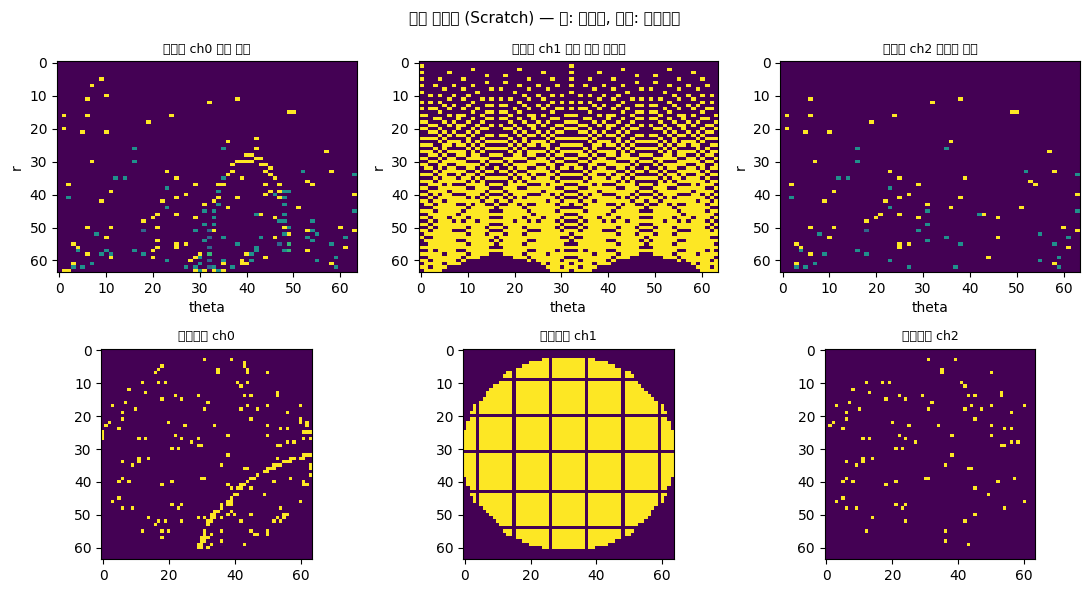

직선 스크래치가 극좌표(위)에서 곡선으로 휘는지 확인할 것.


In [13]:
i = int(np.where(packed_polar.labels == 6)[0][0])      # Scratch 한 장
fig, ax = plt.subplots(2, 3, figsize=(11, 6))
ch = ['결함 밀도', '유효 다이 마스크', '노이즈 밀도']
for c in range(3):
    ax[0, c].imshow(packed_polar.polar[i, c].astype(np.float32), aspect='auto', cmap='viridis')
    ax[0, c].set_title(f'극좌표 ch{c} {ch[c]}', fontsize=9)
    ax[0, c].set_xlabel('theta'); ax[0, c].set_ylabel('r')
    ax[1, c].imshow(packed_cart.cart[i, c].astype(np.float32), cmap='viridis')
    ax[1, c].set_title(f'직교좌표 ch{c}', fontsize=9)
plt.suptitle(f'같은 웨이퍼 (Scratch) — 위: 극좌표, 아래: 직교좌표', fontsize=11)
plt.tight_layout(); plt.show()
print("직선 스크래치가 극좌표(위)에서 곡선으로 휘는지 확인할 것.")


# 10. 공통 설정 (EPOCHS = 100, patience = 20, min_epochs = 30)

**이번 판은 캐시를 재사용하지 않는다.** 조기 종료 설정을 바꿨고, 캐시 키에
`_p20_e100` 접미사가 붙어 옛 결과와 파일이 갈린다. 옛 캐시는 지우지 않는다.

1 fold 스크리닝은 하지 않는다 — 어떤 개입이 의미 있는지 이미 알고 있다.
전 설정을 처음부터 5 fold 로 돌린다(§11). 옛 스크리닝 셀은 부록 A 에 있다.


In [14]:
SEED, BATCH_SIZE, EPOCHS = 42, 64, 100
LR, WD = 1e-4, 1e-5

# 조기 종료. patience 10 은 여유가 3~4 epoch 뿐이었다 — 관측된 최대 갱신 간격이
# 6~7 epoch(PolarCNN fold 2)였다. 30 은 GIN 계열(14~27 수렴)에 낭비가 커서 20 으로 둔다.
# min_epochs 는 상승 곡선 중간에 잘리는 것을 막는다. CartesianCNN fold 0 이 epoch 14 에
# 최고를 찍고 24 에 종료돼 다른 fold(0.902~0.905)보다 낮게 나온 사례가 있다.
PATIENCE, MIN_EPOCHS = 20, 30

HIDDEN, NUM_LAYERS, HEADS = 128, 3, 4

FULL = []           # 5 fold 결과 (result 리스트)

# 그림용 영문 라벨. Colab 기본 폰트에는 한글 글리프가 없어 축 라벨이 네모로 깨진다.
LBL = {"GIN[+가상노드]": "GIN[+VN,sum]", "GIN[+가상노드·평균]": "GIN[+VN,mean]",
       "PolarCNN[−mask]": "PolarCNN[-mask]"}

GIN_BASE  = dict(conv="gin", balanced_sampler=False, use_class_weights=True, jk=None)
CNN_BASE  = dict(conv="gin", balanced_sampler=False, use_class_weights=True, jk=None,
                 build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32))

print(f"EPOCHS={EPOCHS} / patience={PATIENCE} / min_epochs={MIN_EPOCHS}")
print(f"캐시 접미사: {cond_suffix(PATIENCE, EPOCHS)}  (옛 결과와 파일이 갈린다)")


EPOCHS=100 / patience=20 / min_epochs=30
캐시 접미사: _p20_e100  (옛 결과와 파일이 갈린다)


### 파라미터 수 점검 — 용량 통제가 실제로 걸려 있는지

논문의 통제 주장(가상 노드 +1.3%, 직교=극좌표 동일, 풀링 축소 무변화)이
코드에서 실제로 성립하는지 학습 전에 확인한다. 하나라도 틀리면 표3 의
해석이 전부 무너진다.


In [15]:
CFG = {
    "GIN[base]":     lambda: GraphClassifier(conv="gin", hidden=HIDDEN, num_layers=NUM_LAYERS, heads=HEADS),
    "GIN[+가상노드]": lambda: GraphClassifier(conv="gin", hidden=HIDDEN, num_layers=NUM_LAYERS, heads=HEADS,
                                            virtual_node=True),
    "GIN[L5]":       lambda: GraphClassifier(conv="gin", hidden=HIDDEN, num_layers=5, heads=HEADS),
    "GIN[L7]":       lambda: GraphClassifier(conv="gin", hidden=HIDDEN, num_layers=7, heads=HEADS),
    "GIN[h181]":     lambda: GraphClassifier(conv="gin", hidden=180, num_layers=NUM_LAYERS, heads=HEADS),
    "GIN[h256]":     lambda: GraphClassifier(conv="gin", hidden=256, num_layers=NUM_LAYERS, heads=HEADS),
    "PolarCNN":      lambda: PolarCNNClassifier(hidden=HIDDEN, width=32),
    "PolarCNN[w22]": lambda: PolarCNNClassifier(hidden=HIDDEN, width=22),
    "PolarCNN[pool0]": lambda: PolarCNNClassifier(hidden=HIDDEN, width=32, n_pools=0),
    "PolarCNN[pool2]": lambda: PolarCNNClassifier(hidden=HIDDEN, width=32, n_pools=2),
    "CartesianCNN":  lambda: CartesianCNNClassifier(hidden=HIDDEN, width=32),
}
base = count_parameters(CFG["GIN[base]"]())
print(f"{'설정':<18}{'파라미터':>10}   GIN[base] 대비")
for n, f in CFG.items():
    p = count_parameters(f())
    print(f"{n:<18}{p:>10,}   {(p / base - 1) * 100:+7.1f}%")

assert count_parameters(CFG["GIN[base]"]()) == 176979
assert count_parameters(CFG["GIN[+가상노드]"]()) == 179291      # +1.3%, 시야만 바뀐다
assert count_parameters(CFG["PolarCNN"]()) == 191216
assert count_parameters(CFG["CartesianCNN"]()) == 191216       # 극좌표와 완전히 같다
assert count_parameters(CFG["PolarCNN[pool0]"]()) == 191216   # 시야만 줄었다
assert count_parameters(CFG["PolarCNN[pool2]"]()) == 191216   # 파라미터 변화 0%
print("\n논문에 적은 파라미터 수와 일치한다.")


설정                      파라미터   GIN[base] 대비
GIN[base]            176,979      +0.0%
GIN[+가상노드]           179,291      +1.3%
GIN[L5]              243,541     +37.6%
GIN[L7]              310,103     +75.2%
GIN[h181]            347,149     +96.2%
GIN[h256]            698,003    +294.4%
PolarCNN             191,216      +8.0%
PolarCNN[w22]        107,606     -39.2%
PolarCNN[pool0]      191,216      +8.0%
PolarCNN[pool2]      191,216      +8.0%
CartesianCNN         191,216      +8.0%

논문에 적은 파라미터 수와 일치한다.


# 11. 5 fold 실행 — 9종

1 fold 스크리닝은 끝났다(부록 A). 여기서는 선정된 9종을 전부 5 fold 로 돌린다.

**캐시를 재사용하지 않는다.** 조기 종료 설정이 바뀌어 캐시 키에 `_p20_e100` 이
붙었고, 옛 fold 0 결과와 파일이 갈린다. 9종 × 5 fold = **45회 전부 신규 학습**이다.

| 설정 | 왜 |
|---|---|
| `GIN[base]` / `PolarCNN` | 총 격차 (표1·표2) |
| `CartesianCNN` | 격차 분해 — 이미지 표현의 몫 / 극좌표 변환의 몫 |
| `GIN[h256]` / `PolarCNN[w22]` | H4 용량 기각 |
| `PolarCNN[−mask]` | H2 정보 비대칭 |
| `GIN[+가상노드·평균]` | H1 정방향 (고친 구현) |
| `PolarCNN[pool2]` / `PolarCNN[pool0]` | H1 역방향 — 시야만 축소, 파라미터 변화 0% |

**예상 소요 약 14~17시간.** 직전 판 실적이 회당 약 14분(patience 10)이었고,
patience 20 + min_epochs 30 으로 회당 1.3~1.4배가 된다.

**끊겨도 괜찮다.** 결과는 fold 단위로 Drive 에 캐시된다. 세션이 죽으면
셀 2 → 4~19(모듈 정의) → 21 → 25 → 27 → 29 순서로 다시 실행하면 끝난 조합은
건너뛴다. 다만 `FULL` 이 중복 누적되지 않도록 셀 25(`FULL = []`)부터 실행할 것.


In [16]:
# 5 fold 로 올릴 설정.
#
#   GIN[base] / PolarCNN / CartesianCNN   격차 분해 (표3)
#   GIN[h256] / PolarCNN[w22]             H4 용량 기각
#   PolarCNN[−mask]                       H2 마스크
#   GIN[+가상노드·평균]                     H1 정방향 (수정 후)
#   PolarCNN[pool2] / PolarCNN[pool0]     H1 역방향 (시야만 축소, 파라미터 변화 0%)
#
# 제외한 것과 그 이유
#   L5 / L7        파라미터가 함께 늘어 시야와 용량이 분리되지 않는다
#   h181           h256 과 논지가 중복된다
#   가상노드(합)     정규화 결함이 확인된 구현이다
#
# 이름은 1 fold 스크리닝에서 쓴 것과 **글자 하나까지 같아야** fold 0 이 캐시에서 나온다.
FIVE = {
    "GIN[base]":         (GIN_BASE, "polar"),
    "PolarCNN":          (CNN_BASE, "polar"),
    "CartesianCNN":      (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: CartesianCNNClassifier(hidden=HIDDEN, width=32)), "cart"),
    "GIN[h256]":         (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: GraphClassifier(conv="gin", hidden=256,
                                                        num_layers=NUM_LAYERS, heads=HEADS)), "polar"),
    "PolarCNN[w22]":     (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=22)), "polar"),
    "PolarCNN[−mask]":   (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32,
                                                           drop_channels=(1,))), "polar"),
    "GIN[+가상노드·평균]": (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: GraphClassifier(conv="gin", hidden=HIDDEN,
                                                        num_layers=NUM_LAYERS, heads=HEADS,
                                                        virtual_node=True, vn_pool="mean")), "polar"),
    "PolarCNN[pool2]":   (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32,
                                                           n_pools=2)), "polar"),
    "PolarCNN[pool0]":   (dict(conv="gin", use_class_weights=True, jk=None,
                          build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32,
                                                           n_pools=0)), "polar"),
}
FOLDS = [0, 1, 2, 3, 4]

def run5(name, folds=FOLDS):
    """설정 하나를 fold 여러 개로 돌려 FULL 에 쌓는다. 캐시 키가 fold 별로 갈리므로
    §11~16 에서 이미 돈 fold 0 은 다시 학습하지 않는다."""
    cfg, src = FIVE[name]
    packed = packed_polar if src == "polar" else packed_cart
    rs = run_dev_stage(packed, split, {name: cfg}, PREPROC_HASH,
                       split_mode=split_meta["mode"], seed=SEED, epochs=EPOCHS,
                       batch_size=BATCH_SIZE, lr=LR, weight_decay=WD,
                       patience=PATIENCE, min_epochs=MIN_EPOCHS, hidden=HIDDEN,
                       num_layers=NUM_LAYERS, heads=HEADS, num_workers=2,
                       cache_dir=ABL_CACHE, ckpt_dir=ABL_CKPT, folds=folds)
    FULL.extend(rs)
    f1 = np.array([r["test_macro_f1"] for r in rs])
    print(f"\n{name:<22}{f1.mean():.4f} ± {f1.std(ddof=1):.4f}   "
          f"fold별 {np.round(f1, 4).tolist()}")
    print(f"  최고 epoch {[int(r['best_epoch']) for r in rs]}  "
          f"종료 {[int(r['stopped_at']) for r in rs]}")
    return rs




In [17]:
# 9종 사전 점검 — 학습 없이 모델 생성 + 배치 1회 forward (약 2분)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tr_idx, va_idx = split["folds"][0]

print(f"{'설정':<22}{'파라미터':>10}  {'출력':>10}  소스")
for name, (cfg, src_tag) in FIVE.items():
    packed = packed_polar if src_tag == "polar" else packed_cart
    ld = loaders_from_indices(packed, tr_idx[:256], va_idx[:256], batch_size=64,
                              augment=True, seed=SEED, num_workers=0)
    m = (cfg["build"]() if callable(cfg.get("build"))
         else GraphClassifier(conv=cfg["conv"], hidden=HIDDEN,
                              num_layers=NUM_LAYERS, heads=HEADS)).to(device).eval()
    b = next(iter(ld[0])).to(device)
    with torch.no_grad():
        out = model_forward(m, b)
    assert out.shape[1] == 8, f"{name}: 출력이 8클래스가 아니다"
    print(f"{name:<22}{count_parameters(m):>10,}  {str(tuple(out.shape)):>10}  {src_tag}")

print("\n캐시 접미사:", cond_suffix(PATIENCE, EPOCHS))
print("예시 경로:", spec_cache_path(ABL_CACHE, PREPROC_HASH, split_meta["mode"],
                                   "gin", "PolarCNN", 0, SEED, PATIENCE, EPOCHS))

설정                          파라미터          출력  소스
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
GIN[base]                176,979     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
PolarCNN                 191,216     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
CartesianCNN             191,216     (64, 8)  cart
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
GIN[h256]                698,003     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
PolarCNN[w22]            107,606     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
PolarCNN[−mask]          191,216     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
GIN[+가상노드·평균]            179,291     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
PolarCNN[pool2]          191,216     (64, 8)  polar
train 256 / val 256 / eval 256  (증강: True, 균형샘플러: False)
PolarCNN[pool0]        

In [18]:
t0 = time.time()
for _name in FIVE:
    run5(_name)
print(f"\n총 {(time.time() - t0) / 3600:.1f}시간")

장치: cuda | 설정 ['GIN[base]'] | fold [0, 1, 2, 3, 4] | epoch 100

train 14296 / val 3568 / eval 3568  (증강: True, 균형샘플러: False)

--- fold 0 / GIN[base] ---
  (캐시) 검증 macro F1 0.8379
train 14288 / val 3576 / eval 3576  (증강: True, 균형샘플러: False)

--- fold 1 / GIN[base] ---
  (캐시) 검증 macro F1 0.8428
train 14288 / val 3576 / eval 3576  (증강: True, 균형샘플러: False)

--- fold 2 / GIN[base] ---
  (캐시) 검증 macro F1 0.8221
train 14290 / val 3574 / eval 3574  (증강: True, 균형샘플러: False)

--- fold 3 / GIN[base] ---
  (캐시) 검증 macro F1 0.8405
train 14294 / val 3570 / eval 3570  (증강: True, 균형샘플러: False)

--- fold 4 / GIN[base] ---
  (캐시) 검증 macro F1 0.8562

GIN[base]             0.8399 ± 0.0122   fold별 [0.8379, 0.8428, 0.8221, 0.8405, 0.8562]
  최고 epoch [14, 62, 14, 49, 26]  종료 [34, 82, 34, 69, 46]
장치: cuda | 설정 ['PolarCNN'] | fold [0, 1, 2, 3, 4] | epoch 100

train 14296 / val 3568 / eval 3568  (증강: True, 균형샘플러: False)

--- fold 0 / PolarCNN ---
  (캐시) 검증 macro F1 0.9327
train 14288 / val 3576 / eval 3576  (증강

# 12. 표1 · 표2 — 논문에 그대로 들어가는 형태


In [19]:
def f1_by_fold(name):
    d = {r["fold"]: r["test_macro_f1"] for r in FULL if r["name"] == name}
    return np.array([d[k] for k in FOLDS], dtype=float)

# 표1 — 설정별 macro F1
rows = []
for n in FIVE:
    v = f1_by_fold(n)
    rows.append({"설정": n, "macro_F1": v.mean(), "fold_std": v.std(ddof=1),
                 "파라미터": int([r for r in FULL if r["name"] == n][0]["params"])})
tab1 = pd.DataFrame(rows)
print("표1 — 5 fold 평균")
print(tab1.round(4).to_string(index=False))
print(f"\n{FOLD_SD_FOOTNOTE}\n")

# 표2 — fold 대응 비교. 분할에서 오는 변동이 상쇄돼 평균 비교보다 검출력이 높다.
PAIRS = [("GIN[base]", "PolarCNN",           "이미지 vs 그래프 (총 격차)"),
         ("GIN[base]", "CartesianCNN",       "H3 이미지 표현의 몫"),
         ("CartesianCNN", "PolarCNN",        "H3 극좌표 변환의 몫"),
         ("GIN[base]", "GIN[+가상노드·평균]",  "H1 정방향 (전역 시야)"),
         ("PolarCNN", "PolarCNN[pool2]",   "H1 역방향 (시야 75%→44%)"),
         ("PolarCNN", "PolarCNN[pool0]",   "H1 역방향 (시야 75%→17%)"),
         ("GIN[base]", "GIN[h256]",          "H4 GIN 4배"),
         ("PolarCNN", "PolarCNN[w22]",       "H4 CNN 절반"),
         ("PolarCNN", "PolarCNN[−mask]",     "H2 마스크 제거"),
         ("GIN[h256]", "PolarCNN[w22]",      "H4 결정타: 4배 GIN vs 절반 CNN")]
rows = []
for a, b, why in PAIRS:
    p = paired_comparison(FULL, a, b)
    rows.append({"의미": why, "기준": a, "비교": b, "평균차": p["평균차"],
                 "표준편차": p["표준편차"], "개선fold": f"{p['개선fold']}/{p['fold수']}"})
tab2 = pd.DataFrame(rows)
print("표2 — fold 대응 비교 (비교 − 기준)")
print(tab2.round(4).to_string(index=False))
print("\nfold 5개짜리 부호검정의 최소 단측 p 는 1/2^5 = 0.031 이다.")
print("'개선 5/5 fold' 가 이 설계로 낼 수 있는 가장 강한 주장이며 그 이상은 불가능하다.")


표1 — 5 fold 평균
             설정  macro_F1  fold_std   파라미터
      GIN[base]    0.8399    0.0122 176979
       PolarCNN    0.9153    0.0109 191216
   CartesianCNN    0.9219    0.0117 191216
      GIN[h256]    0.8402    0.0167 698003
  PolarCNN[w22]    0.9118    0.0060 107606
PolarCNN[−mask]    0.9049    0.0078 191216
  GIN[+가상노드·평균]    0.8607    0.0133 179291
PolarCNN[pool2]    0.9086    0.0067 191216
PolarCNN[pool0]    0.8563    0.0118 191216

fold 간 학습 집합이 상호 중첩되므로 이 편차는 독립 표본의 신뢰구간이 아니다.

표2 — fold 대응 비교 (비교 − 기준)
                      의미           기준              비교     평균차   표준편차 개선fold
       이미지 vs 그래프 (총 격차)    GIN[base]        PolarCNN  0.0754 0.0161    5/5
            H3 이미지 표현의 몫    GIN[base]    CartesianCNN  0.0820 0.0223    5/5
            H3 극좌표 변환의 몫 CartesianCNN        PolarCNN -0.0065 0.0100    1/5
          H1 정방향 (전역 시야)    GIN[base]   GIN[+가상노드·평균]  0.0208 0.0126    5/5
     H1 역방향 (시야 75%→44%)     PolarCNN PolarCNN[pool2] -0.0067 0.0050    0/5
     H1 역방향 (시야 75%→17%)

# 13. 표3 — 격차 분해

1 fold 에서는 이미지 표현 66% / 극좌표 변환 34% 였고, 극좌표 몫(0.0306)이
판별 해상도 0.04 안에 있어 확정할 수 없었다. fold 안에서 짝지어 빼면
분할 변동이 상쇄되므로 5 fold 에서는 훨씬 좁은 구간으로 말할 수 있다.


In [20]:
# 표3 — 격차 분해. fold 안에서 빼야 분할 변동이 상쇄된다.
tot = f1_by_fold("PolarCNN")     - f1_by_fold("GIN[base]")
img = f1_by_fold("CartesianCNN") - f1_by_fold("GIN[base]")
pol = f1_by_fold("PolarCNN")     - f1_by_fold("CartesianCNN")
assert np.allclose(tot, img + pol), "분해가 맞지 않는다"

print("표3 — 총 격차의 분해 (fold 별)")
dec = pd.DataFrame({"fold": FOLDS, "총격차": tot, "이미지표현": img, "극좌표변환": pol})
print(dec.round(4).to_string(index=False))
print(f"\n총 격차      {tot.mean():+.4f} ± {tot.std(ddof=1):.4f}")
print(f"이미지 표현  {img.mean():+.4f} ± {img.std(ddof=1):.4f}   "
      f"({img.mean() / tot.mean() * 100:.0f}%, 개선 {(img > 0).sum()}/5 fold)")
print(f"극좌표 변환  {pol.mean():+.4f} ± {pol.std(ddof=1):.4f}   "
      f"({pol.mean() / tot.mean() * 100:.0f}%, 개선 {(pol > 0).sum()}/5 fold)")
print("\n1 fold 값은 66% / 34% 였다. 5 fold 에서 몫이 얼마나 움직이는지 볼 것.")
print("극좌표 몫이 5/5 fold 로 양수가 아니면 제목에서 '극좌표'를 빼고")
print("'이미지 표현 vs 그래프 표현' 으로 주장을 좁혀야 한다.")

cap = f1_by_fold("PolarCNN[w22]") - f1_by_fold("GIN[h256]")
print(f"\nH4 결정타: 절반 CNN(107,606) − 4배 GIN(698,003) = {cap.mean():+.4f} "
      f"(우세 {(cap > 0).sum()}/5 fold)")
print("5/5 fold 로 양수면 '용량이 아니라 표현' 이라는 주장이 성립한다.")

tab1.to_csv(f"{SPEC_DIR}/ablation_5fold_table1.csv", index=False)
tab2.to_csv(f"{SPEC_DIR}/ablation_5fold_table2.csv", index=False)
dec.to_csv(f"{SPEC_DIR}/ablation_5fold_decomp.csv", index=False)
print("\n저장:", SPEC_DIR + "/ablation_5fold_*.csv")


표3 — 총 격차의 분해 (fold 별)
 fold    총격차  이미지표현   극좌표변환
    0 0.0948 0.0955 -0.0007
    1 0.0687 0.0718 -0.0031
    2 0.0905 0.1137 -0.0232
    3 0.0628 0.0705 -0.0077
    4 0.0604 0.0583  0.0021

총 격차      +0.0754 ± 0.0161
이미지 표현  +0.0820 ± 0.0223   (109%, 개선 5/5 fold)
극좌표 변환  -0.0065 ± 0.0100   (-9%, 개선 1/5 fold)

1 fold 값은 66% / 34% 였다. 5 fold 에서 몫이 얼마나 움직이는지 볼 것.
극좌표 몫이 5/5 fold 로 양수가 아니면 제목에서 '극좌표'를 빼고
'이미지 표현 vs 그래프 표현' 으로 주장을 좁혀야 한다.

H4 결정타: 절반 CNN(107,606) − 4배 GIN(698,003) = +0.0717 (우세 5/5 fold)
5/5 fold 로 양수면 '용량이 아니라 표현' 이라는 주장이 성립한다.

저장: /content/drive/MyDrive/ACK2026_Wafer/Train_Model/spec_v1/ablation_5fold_*.csv


# 14. 논문용 그림


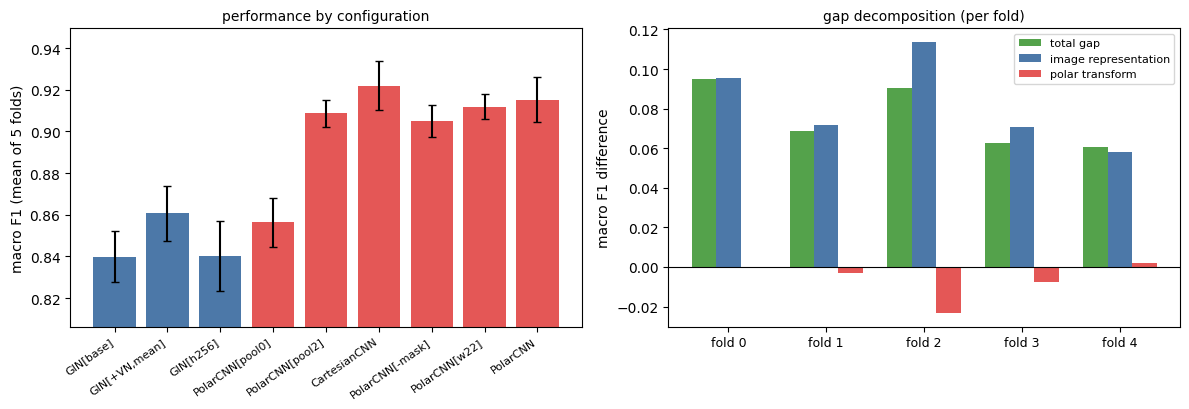

In [21]:
# 그림 라벨은 영문으로 둔다. Colab 기본 폰트에는 한글 글리프가 없어 네모로 깨진다.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

order5 = ["GIN[base]", "GIN[+가상노드·평균]", "GIN[h256]",
          "PolarCNN[pool0]", "PolarCNN[pool2]",
          "CartesianCNN", "PolarCNN[−mask]", "PolarCNN[w22]", "PolarCNN"]
order5 = [n for n in order5 if any(r["name"] == n for r in FULL)]
mu = [f1_by_fold(n).mean() for n in order5]
sd = [f1_by_fold(n).std(ddof=1) for n in order5]
cols = ['#4C78A8' if n.startswith("GIN") else '#E45756' for n in order5]
ax[0].bar(range(len(order5)), mu, yerr=sd, capsize=3, color=cols)
ax[0].set_xticks(range(len(order5)))
ax[0].set_xticklabels([LBL.get(n, n) for n in order5], rotation=35, ha='right', fontsize=8)
ax[0].set_ylabel('macro F1 (mean of 5 folds)')
ax[0].set_ylim(min(mu) * 0.96, max(mu) * 1.03)
ax[0].set_title('performance by configuration', fontsize=10)

w = 0.25
for i, (v, lab, cc) in enumerate([(tot, 'total gap', '#54A24B'),
                                  (img, 'image representation', '#4C78A8'),
                                  (pol, 'polar transform', '#E45756')]):
    ax[1].bar(np.arange(len(FOLDS)) + (i - 1) * w, v, w, label=lab, color=cc)
ax[1].axhline(0, c='k', lw=0.8)
ax[1].set_xticks(range(len(FOLDS)))
ax[1].set_xticklabels([f'fold {k}' for k in FOLDS], fontsize=9)
ax[1].set_ylabel('macro F1 difference')
ax[1].set_title('gap decomposition (per fold)', fontsize=10)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


# 15. 마무리 점검

- [ ] 표1·표2·표3 CSV 가 `spec_v1/` 에 저장됐다
- [ ] 극좌표 몫이 5/5 fold 양수인가 → 아니면 제목에서 "극좌표" 를 빼고
      "이미지 표현 vs 그래프 표현" 으로 좁힌다
- [ ] `PolarCNN[w22]` > `GIN[h256]` 이 5/5 fold 인가 → H4 용량 기각의 결정타
- [ ] `GIN[+가상노드·평균]` 이 H1 을 어느 쪽으로 가리키는가
- [ ] §17 의 1 fold 값은 본문에 넣지 않는다 (탐색용)

> **봉인 집합은 열지 않았다.** 이 노트북은 `split['dev']` 만 쓴다.
> 확정된 `GIN[base]` 봉인 결과 0.8662 는 그대로 유지된다.


In [22]:
done = sorted({r["name"] for r in FULL})
print("5 fold 완료:", done)
missing = [n for n in FIVE if n not in done]
print("남은 설정:", missing if missing else "없음")
print(f"\n봉인 집합 개봉 여부: 이 노트북은 split['final'] 을 한 번도 만지지 않는다.")
print("확정된 GIN[base] 봉인 결과 0.8662 는 그대로 유지된다.")


5 fold 완료: ['CartesianCNN', 'GIN[+가상노드·평균]', 'GIN[base]', 'GIN[h256]', 'PolarCNN', 'PolarCNN[pool0]', 'PolarCNN[pool2]', 'PolarCNN[w22]', 'PolarCNN[−mask]']
남은 설정: 없음

봉인 집합 개봉 여부: 이 노트북은 split['final'] 을 한 번도 만지지 않는다.
확정된 GIN[base] 봉인 결과 0.8662 는 그대로 유지된다.


# 부록 A. 1 fold 스크리닝 기록 — **실행하지 않는다**

여기 있는 셀들은 어떤 개입이 의미 있는지 모르던 단계에서 fold 하나로 훑어본
기록이다. 그 단계는 끝났고 본 실험(§11)이 전 설정을 5 fold 로 돌린다.

**돌리지 말 것.** 판별 해상도가 |차이| > 0.04 뿐이고, 1 fold 값이 5 fold 보다 크게
나오는 경향이 관측됐다(극좌표 몫 0.0306 → 0.0116). 설정당 GPU 시간만 쓴다.

남겨 두는 이유는 세 가지다.

1. `GIN[L5]` / `GIN[L7]` / `GIN[h181]` / `GIN[+가상노드](합)` 은 5 fold 목록에 없다.
   이 셀들이 그 수치의 유일한 출처다.
2. 1 fold 가 5 fold 를 얼마나 부풀리는지 보여주는 사례다.
3. `screen_verdict` 의 전제 오류(역방향 개입에 "버림" 이 찍힌 것)를 재현할 수 있다.

돌리려면 아래 헬퍼 셀부터 순서대로 실행해야 한다. 다만 캐시 키에 `_p20_e100` 이
붙어 **옛 1 fold 캐시는 더 이상 맞지 않는다** — 전부 새로 학습한다. 아래 수치를
다시 얻으려면 그 비용을 감수해야 한다.


In [ ]:
# 부록 전용 헬퍼. 본 실험(§11~§15)은 이것 없이 돈다.
FOLD = 0
RES = {}

def run(name, cfg, packed, fold=FOLD):
    """설정 하나를 fold 하나로 학습한다. 캐시가 있으면 즉시 불러온다."""
    rs = run_dev_stage(packed, split, {name: cfg}, PREPROC_HASH,
                       split_mode=split_meta["mode"], seed=SEED, epochs=EPOCHS,
                       batch_size=BATCH_SIZE, lr=LR, weight_decay=WD,
                       patience=PATIENCE, min_epochs=MIN_EPOCHS, hidden=HIDDEN,
                       num_layers=NUM_LAYERS, heads=HEADS, num_workers=2,
                       cache_dir=ABL_CACHE, ckpt_dir=ABL_CKPT, folds=[fold])
    RES[name] = rs[0]
    return rs[0]

def show(name, ref=None):
    r = RES[name]
    line = f"{name:<22}{r['test_macro_f1']:.4f}"
    if ref and ref in RES:
        d = r["test_macro_f1"] - RES[ref]["test_macro_f1"]
        v, _ = screen_verdict(d)
        line += f"   {ref} 대비 {d:+.4f}  [{v}]"
    print(line)

print(f"1 fold 판별 해상도: |차이| > {2*SCREEN_SD:.3f}")


### A.1 기준선 두 개 (1 fold)


In [ ]:
run("GIN[base]",  GIN_BASE, packed_polar)
run("PolarCNN",   CNN_BASE, packed_polar)
print()
show("GIN[base]"); show("PolarCNN", "GIN[base]")
print(f"\n참고 (EPOCHS=50 일 때): GIN 0.8418 ± 0.0159 / PolarCNN 0.9060 ± 0.0052")
print("epoch 상한을 올려 두 값이 얼마나 움직였는지 확인할 것.")


### A.2 H2 — 정보 비대칭: CNN 마스크 채널 제거


CNN 은 유효 다이 마스크를 **전 영역** 받고, 그래프는 결함 주변 반경 4다이
(`local_ratio`)만 받는다. 이 채널을 없앴을 때 얼마나 떨어지는지가
**"표현의 차이인가 정보량의 차이인가"** 에 대한 정량적 답이다.

동시에 **로트 지문 우려**도 해소된다 — 웨이퍼 형상은 제품·로트마다 다르고 현재
분할은 같은 로트가 섞여 있어, 마스크가 지름길로 쓰였을 가능성이 있다.

크게 떨어지면 → 마스크가 CNN 우위의 주원인. 정보량을 맞추는 후속 실험이 필요.
거의 안 떨어지면 → 우위는 결함 배치 자체에서 온 것.


In [ ]:
run("PolarCNN[−mask]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32, drop_channels=(1,))), packed_polar)
print()
show("PolarCNN[−mask]", "PolarCNN")


### A.3 H1 정방향 — 그래프에 전역 시야 부여 (가상 노드)


가상 노드는 그래프마다 노드 하나를 두고 모든 노드와 잇는 것과 같다. 임의의 두
노드가 2 hop 안에 연결되므로 **시야만** 전역이 된다.

**파라미터는 +1.3% 만 는다**(176,979 → 179,291). 층을 5개로 늘리면 +37.6% 이므로,
가상 노드가 효과를 내면 "용량이 늘어서"라는 반박이 봉쇄된다.

초기값이 0이라 학습 시작 시점에는 기존 GIN 과 완전히 동일하다.

## ⚠️ 첫 실행은 무효다

첫 구현은 노드 -> 가상 노드 집계를 `global_add_pool` 로 했다. 이 데이터의 노드 수는
웨이퍼마다 240~5,494개다.

```
vn = vn + vn_mlp(global_add_pool(h, batch))     # 노드 240~5,494개의 합
```

합 벡터의 크기가 노드 수에 비례하고, 그 값이 매 층 **모든 노드에** 더해진다.
게다가 층을 지날 때마다 증폭돼 3층이면 크기비가 **12,510배**까지 벌어진다(아래 셀에서
직접 잰다). 큰 웨이퍼에서는 노드 특징이 가상 노드에 완전히 덮이고, 작은 웨이퍼에서는
사실상 아무 일도 일어나지 않는다.

그 결과가 정확히 그렇게 나왔다.

```
GIN[+가상노드](합)  0.7976    GIN[base] 대비 −0.0325
  Near-full  +0.1787     ← 노드가 가장 많은 클래스만 올랐다
  Donut      −0.1843
  Edge-Loc   −0.1062
  최고 epoch 53 (GIN[base] 는 21) — 학습도 불안정했다
```

이건 **전역 시야의 효과가 아니라 정규화 결함의 효과**다. 이 수치로는 H1 을 어느
쪽으로도 판정할 수 없다.

**고친 것**: `global_mean_pool` 로 집계한다(`vn_pool="mean"`, 기본값).
파라미터 수는 두 방식이 완전히 같으므로(179,291) 용량 반박은 여전히 봉쇄된다.
그래프 크기 정보는 readout 의 `log1p(sum)` 과 그래프 스칼라가 이미 나르고 있다.


In [ ]:
# 이름 두 개를 쓰는 이유: 캐시 키가 설정 이름으로 만들어지므로, 고친 구현에
# 옛 이름을 그대로 쓰면 결함이 있던 실행 결과(0.7976)를 그냥 불러와 버린다.
#
#   GIN[+가상노드]        vn_pool="sum"   결함 있던 첫 구현. 캐시가 이미 있어 즉시 로드된다.
#   GIN[+가상노드·평균]    vn_pool="mean"  고친 구현. H1 정방향은 이 값으로 판정한다.
run("GIN[+가상노드]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: GraphClassifier(conv="gin", hidden=HIDDEN,
                                   num_layers=NUM_LAYERS, heads=HEADS,
                                   virtual_node=True, vn_pool="sum")), packed_polar)
run("GIN[+가상노드·평균]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: GraphClassifier(conv="gin", hidden=HIDDEN,
                                   num_layers=NUM_LAYERS, heads=HEADS,
                                   virtual_node=True, vn_pool="mean")), packed_polar)
print()
show("GIN[+가상노드]", "GIN[base]")
show("GIN[+가상노드·평균]", "GIN[base]")
print("\n두 값의 차이는 파라미터가 아니라 집계 정규화 하나에서만 온다 (둘 다 179,291).")
print("학습 안정성도 함께 볼 것 — 결함 구현은 최고 epoch 53, GIN[base] 는 21 이었다.")
for n in ("GIN[base]", "GIN[+가상노드]", "GIN[+가상노드·평균]"):
    if n in RES:
        print(f"  {n:<22} 최고 epoch {int(RES[n]['best_epoch']):>3} / 종료 {int(RES[n]['stopped_at']):>3}")


### A.4 H1 역방향 — CNN 에서 시야 뺏기 (풀링 축소)


**파라미터가 전혀 바뀌지 않는다.** conv 4개는 그대로 두고 MaxPool 만 뺀다.
풀링 하나당 최종 화소가 보는 범위가 절반이 된다.

```
n_pools=4  64 -> 4    전역 시야 (기준)
n_pools=2  64 -> 16   시야 1/4
n_pools=0  64 -> 64   국소만
```

**커버율이 낮았던 클래스(Random, Edge-Ring)에서 유독 많이 떨어지면** 수용 영역
가설의 결정적 증거다. 다른 이유로는 그런 선택적 패턴이 나오지 않는다.


In [ ]:
run("PolarCNN[pool2]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32, n_pools=2)), packed_polar)
run("PolarCNN[pool0]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=32, n_pools=0)), packed_polar)
print()
show("PolarCNN[pool2]", "PolarCNN")
show("PolarCNN[pool0]", "PolarCNN")


### A.5 H1 용량-반응 — 층 수 늘리기


hop 이 늘면 시야가 넓어진다. 단조 개선이면 H1 을 지지한다.

다만 층을 늘리면 **파라미터도 함께 는다**(+37.6%, +75.2%). 그래서 이 실험만으로는
"용량 때문"이라는 반박을 못 막고, 가상 노드(파라미터 +1.3%)와 함께 봐야 한다.

GNN 은 깊어지면 노드 특징이 평준화(over-smoothing)되므로 어느 지점에서 꺾일 수 있다.


In [ ]:
run("GIN[L5]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: GraphClassifier(conv="gin", hidden=HIDDEN, num_layers=5,
                                   heads=HEADS)), packed_polar)
run("GIN[L7]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: GraphClassifier(conv="gin", hidden=HIDDEN, num_layers=7,
                                   heads=HEADS)), packed_polar)
print()
show("GIN[L5]", "GIN[base]")
show("GIN[L7]", "GIN[base]")


### A.6 H4 — 용량이 원인인가 (파라미터 스케일링)


GIN 을 키우고 CNN 을 줄여, **용량으로는 격차가 설명되지 않음**을 보인다.

GIN 을 4배로 키워도 CNN 191K 를 못 따라잡으면 용량 가설은 기각된다.
반대로 CNN 을 절반으로 줄여도 GIN 을 이기면 더욱 강한 증거다.


In [ ]:
run("GIN[h181]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: GraphClassifier(conv="gin", hidden=180, num_layers=NUM_LAYERS,
                                   heads=HEADS)), packed_polar)
run("GIN[h256]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: GraphClassifier(conv="gin", hidden=256, num_layers=NUM_LAYERS,
                                   heads=HEADS)), packed_polar)
run("PolarCNN[w22]", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: PolarCNNClassifier(hidden=HIDDEN, width=22)), packed_polar)
print()
show("GIN[h181]", "GIN[base]")
show("GIN[h256]", "GIN[base]")
show("PolarCNN[w22]", "PolarCNN")


### A.7 H3 — 극좌표인가 이미지인가 (직교좌표 CNN)


**이 실험이 없으면 제목에 "극좌표"를 넣을 수 없다.** 지금까지 잰 것은
"이미지 vs 그래프"이지 "극좌표 vs 그래프"가 아니다.

아키텍처·파라미터·학습 설정이 극좌표 CNN 과 **완전히 동일**하고, 바뀌는 것은
입력 이미지와 순환 패딩 해제뿐이다.

> **명시할 한계**: 극좌표에서 회전 증강은 theta 축 roll 이라 무손실이지만,
> 직교좌표는 이중선형 보간이 들어간다. 이는 직교좌표 표현이 회전에 대해 갖는
> 고유한 성질이지 설계의 불공정이 아니다 — 오히려 극좌표를 쓰는 이유 중 하나다.
> 회전 각도 집합은 동일하게 맞췄다.


In [ ]:
run("CartesianCNN", dict(conv="gin", use_class_weights=True, jk=None,
     build=lambda: CartesianCNNClassifier(hidden=HIDDEN, width=32)), packed_cart)
print()
show("CartesianCNN", "PolarCNN")


### A.8 종합 (1 fold 스크리닝)

`격차 대비` 열이 핵심이다. GIN 과 CNN 의 격차를 100% 로 놓고, 각 개입이 그 격차의
몇 %를 **회복**(그래프 개선)하거나 **재현**(CNN 저하)하는지 본다.

정방향 회복률과 역방향 재현율이 비슷하게 나오면 그 요인이 주원인이라는
정량적 주장이 된다.

**여기 숫자는 전부 탐색용이다.** 논문 표는 §18 에서 나온다.


In [ ]:
assert "GIN[base]" in RES and "PolarCNN" in RES, "먼저 기준선 셀을 실행할 것"
g, c = RES["GIN[base]"]["test_macro_f1"], RES["PolarCNN"]["test_macro_f1"]
gap = c - g
print(f"기준 격차: PolarCNN {c:.4f} − GIN {g:.4f} = {gap:+.4f}\n")

REF = {"PolarCNN[−mask]": "PolarCNN", "PolarCNN[pool2]": "PolarCNN",
       "PolarCNN[pool0]": "PolarCNN", "PolarCNN[w22]": "PolarCNN",
       "CartesianCNN": "PolarCNN", "GIN[+가상노드]": "GIN[base]",
       "GIN[+가상노드·평균]": "GIN[base]",
       "GIN[L5]": "GIN[base]", "GIN[L7]": "GIN[base]",
       "GIN[h181]": "GIN[base]", "GIN[h256]": "GIN[base]"}
KIND = {"GIN[+가상노드]": "H1 정방향(결함)", "GIN[+가상노드·평균]": "H1 정방향",
        "PolarCNN[pool2]": "H1 역방향",
        "PolarCNN[pool0]": "H1 역방향", "GIN[L5]": "H1 용량반응",
        "GIN[L7]": "H1 용량반응", "PolarCNN[−mask]": "H2 정보",
        "CartesianCNN": "H3 표현", "GIN[h181]": "H4 용량",
        "GIN[h256]": "H4 용량", "PolarCNN[w22]": "H4 용량"}

rows = []
for name, r in RES.items():
    if name in ("GIN[base]", "PolarCNN"):
        continue
    ref = REF.get(name, "GIN[base]")
    d = r["test_macro_f1"] - RES[ref]["test_macro_f1"]
    kind = KIND.get(name, "-")
    # 역방향 개입은 **크게 떨어지는 것이 가설 지지**다. 기본 판정을 쓰면
    # PolarCNN[pool0] 처럼 가장 강한 증거에 "버림" 이 찍혀 걸러진다.
    v, _ = screen_verdict(d, direction="decrease" if kind == "H1 역방향" else "increase")
    rows.append({"가설": kind, "설정": name,
                 "macro_F1": r["test_macro_f1"], "기준": ref, "차이": d,
                 "격차대비": abs(d) / gap * 100 if gap else np.nan, "판정": v})

df = pd.DataFrame(rows).sort_values(["가설", "설정"])
print("=" * 96)
print(df.round(4).to_string(index=False))
print("=" * 96)
print(f"\n판별 해상도 |차이| > {2*SCREEN_SD:.3f}. 그 안이면 '판정 불가' 이며 5 fold 가 필요하다.")
print("`H1 정방향(결함)` 행은 정규화 결함이 있던 구현이다. 판정 근거로 쓰지 말 것.")


### 클래스별로 어디서 무너지는가

수용 영역 가설이 맞다면 **커버율이 낮았던 클래스에서 선택적으로** 떨어져야 한다.

```
3-hop 커버율:  Near-full 8.5%  Random 12.9%  Edge-Ring 16.8%  Donut 18.4%
               Edge-Loc 29.1%  Center 36.4%  Loc 37.0%  Scratch 42.6%
```


In [ ]:
COVER = {"Near-full": 8.5, "Random": 12.9, "Edge-Ring": 16.8, "Donut": 18.4,
         "Edge-Loc": 29.1, "Center": 36.4, "Loc": 37.0, "Scratch": 42.6}

pick = [n for n in ("PolarCNN[pool0]", "PolarCNN[pool2]", "GIN[+가상노드·평균]",
                    "GIN[+가상노드]", "PolarCNN[−mask]", "CartesianCNN") if n in RES]
tbl = pd.DataFrame({"커버율%": [COVER[n] for n in names]}, index=names)
for n in pick:
    ref = REF[n]
    tbl[n] = RES[n]["per_class_f1"] - RES[ref]["per_class_f1"]
print("클래스별 F1 변화 (각자의 기준 대비)")
print(tbl.sort_values("커버율%").round(4).to_string())

for n in pick:
    v = tbl[n].values
    r = np.corrcoef(tbl["커버율%"].values, v)[0, 1]
    print(f"\n{n:<18} 커버율과의 상관 r = {r:+.3f}")
print("\nx = 3-hop 커버율, y = ΔF1 이므로 **음의 상관은 커버율이 높았던 클래스가")
print("더 크게 떨어졌다는 뜻**이다. 실제로 pool0 에서 Scratch(커버율 42.6%)가 −0.1402 로")
print("가장 크게 무너졌고 Near-full(8.5%)은 −0.0612 였다.")
print("3-hop 커버율이 '전역 시야 필요도' 의 대리 변수로 적절한지는 재검토가 필요하다.")
print("클래스 8개짜리 상관이라 p 값은 붙이지 않는다. 방향만 본다.")


### A.9 그림 — 개입별 격차 회복/재현


In [ ]:
order = [n for n in ["GIN[base]", "GIN[+가상노드]", "GIN[+가상노드·평균]",
                     "GIN[L5]", "GIN[L7]",
                     "GIN[h181]", "GIN[h256]", "CartesianCNN", "PolarCNN[−mask]",
                     "PolarCNN[pool0]", "PolarCNN[pool2]", "PolarCNN[w22]",
                     "PolarCNN"] if n in RES]
vals = [RES[n]["test_macro_f1"] for n in order]
cols = ['#4C78A8' if n.startswith("GIN") else '#E45756' for n in order]

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.bar(range(len(order)), vals, color=cols)
ax.axhline(g, ls=':', c='#4C78A8', lw=1.4, label=f'GIN 기준 {g:.4f}')
ax.axhline(c, ls=':', c='#E45756', lw=1.4, label=f'PolarCNN 기준 {c:.4f}')
for i, v in enumerate(vals):
    ax.text(i, v + 0.004, f'{v:.3f}', ha='center', fontsize=8)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([LBL.get(n, n) for n in order], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('macro F1 (fold %d)' % FOLD)
ax.set_ylim(min(vals) * 0.96, max(vals) * 1.03)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

out = df.copy()
out.to_csv(f"{SPEC_DIR}/ablation_table.csv", index=False)
print("저장:", f"{SPEC_DIR}/ablation_table.csv")
